# Analyzing the Global COVID-19 Pandemic: A Data-Driven Case Study

**Objective:** To analyze the COVID-19 dataset to uncover trends, compare national responses, and understand the pandemic's progression over time.

**Dataset:** Time-series data for confirmed cases, deaths, and recoveries.

**Methodology:** This analysis involves several key steps which we will walk through:
1.  **Data Loading & Exploration:** Initial loading and structural assessment of the data.
2.  **Data Cleaning & Preparation:** Addressing missing values and inconsistencies to ensure data quality.
3.  **Data Transformation:** Reshaping the data from a wide to a long format to facilitate time-series analysis.
4.  **Analysis & Visualization:** Answering specific questions by querying the data and creating insightful visualizations.

# Importing all necessary libraries

First, we import the necessary Python libraries. We'll primarily use `pandas` for data manipulation and `matplotlib`/`seaborn` for plotting.

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_rows',100)

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

plt.style.use('dark_background')
plt.rcParams['figure.figsize'] = (14, 9)
plt.rcParams['font.size'] = 14
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Roboto', 'Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['axes.edgecolor'] = '#555555'
plt.rcParams['axes.linewidth'] = 1.0
plt.rcParams['axes.labelcolor'] = '#CCCCCC'
plt.rcParams['axes.facecolor'] = '#1E1E1E'
plt.rcParams['grid.color'] = '#333333'
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.linewidth'] = 0.5
plt.rcParams['xtick.color'] = '#AAAAAA'
plt.rcParams['ytick.color'] = '#AAAAAA'
plt.rcParams['xtick.direction'] = 'out'
plt.rcParams['ytick.direction'] = 'out'
plt.rcParams['lines.linewidth'] = 2.0
plt.rcParams['lines.color'] = '#88CCEE'
plt.rcParams['text.color'] = '#E0E0E0'
plt.rcParams['axes.titlecolor'] = '#E0E0E0'
plt.rcParams['legend.facecolor'] = '#2A2A2A'
plt.rcParams['legend.edgecolor'] = '#555555'
plt.rcParams['legend.fontsize'] = 'large'
plt.rcParams['savefig.facecolor'] = '#121212'

def millions_formatter(x, pos):
    return f'{x / 1e6:.0f}M'

def thousands_formatter(x, pos):
    return f'{x / 1e3:.0f}K'

def readable_formatter(x, pos):
    if x >= 1e6:
        return f'{x / 1e6:.1f}M'
    elif x >= 1e3:
        return f'{x / 1e3:.0f}K'
    else:
        return f'{x:,.0f}'

# Question 1: Data Loading

## **Q1.1**: How do you load the COVID-19 datasets for confirmed cases, deaths, and recoveries into Python using Pandas?

*My first step is to load the three separate CSV files—confirmed cases, deaths, and recoveries—into pandas DataFrames. This provides the foundation for all subsequent analysis.*

In [ ]:
covid_19_confirmed_dataset_path = "/content/drive/MyDrive/case-study-pandas/covid_19_confirmed_v1_lyst1747728690432.csv"
covid_19_deaths_dataset_path = "/content/drive/MyDrive/case-study-pandas/covid_19_deaths_v1_lyst1747728711771.csv"
covid_19_recovered_dataset_path = "/content/drive/MyDrive/case-study-pandas/covid_19_recovered_v1_lyst1747728719904.csv"

confirmed = pd.read_csv(covid_19_confirmed_dataset_path)
deaths = pd.read_csv(covid_19_deaths_dataset_path)
recovered = pd.read_csv(covid_19_recovered_dataset_path)

In [ ]:
# checking the datasets

confirmed.head()

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,5/20/21,5/21/21,5/22/21,5/23/21,5/24/21,5/25/21,5/26/21,5/27/21,5/28/21,5/29/21
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,64575,65080,65486,65728,66275,66903,67743,68366,69130,70111
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,132118,132153,132176,132209,132215,132229,132244,132264,132285,132297
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,126156,126434,126651,126860,127107,127361,127646,127926,128198,128456
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,13569,13569,13569,13569,13569,13664,13671,13682,13693,13693
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,31661,31909,32149,32441,32623,32933,33338,33607,33944,34180


In [ ]:
deaths.head()

,Column1,Column2,Column3,Column4,Column5,Column6,Column7,Column8,Column9,Column10,...,Column489,Column490,Column491,Column492,Column493,Column494,Column495,Column496,Column497,Column498
0,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,5/20/21,5/21/21,5/22/21,5/23/21,5/24/21,5/25/21,5/26/21,5/27/21,5/28/21,5/29/21
1,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,2772,2782,2792,2802,2812,2836,2855,2869,2881,2899
2,NaN,Albania,41.1533,20.1683,0,0,0,0,0,0,...,2440,2441,2442,2444,2445,2447,2447,2447,2448,2449
3,NaN,Algeria,28.0339,1.6596,0,0,0,0,0,0,...,3401,3405,3411,3418,3426,3433,3440,3448,3455,3460
4,NaN,Andorra,42.5063,1.5218,0,0,0,0,0,0,...,127,127,127,127,127,127,127,127,127,127


In [ ]:
recovered.head()

,Column1,Column2,Column3,Column4,Column5,Column6,Column7,Column8,Column9,Column10,...,Column489,Column490,Column491,Column492,Column493,Column494,Column495,Column496,Column497,Column498
0,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,5/20/21,5/21/21,5/22/21,5/23/21,5/24/21,5/25/21,5/26/21,5/27/21,5/28/21,5/29/21
1,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,55687,55790,55889,56035,56295,56518,56711,56962,57119,57281
2,NaN,Albania,41.1533,20.1683,0,0,0,0,0,0,...,127869,128425,128601,128732,128826,128907,128978,129042,129097,129215
3,NaN,Algeria,28.0339,1.6596,0,0,0,0,0,0,...,87902,88066,88208,88346,88497,88672,88861,89040,89232,89419
4,NaN,Andorra,42.5063,1.5218,0,0,0,0,0,0,...,13234,13234,13234,13234,13234,13263,13381,13405,13416,13416


# Question 2: Data Exploration

## **Q2.1**: After loading the datasets, what is the structure of each dataset in terms of rows, columns, and data types?

In [ ]:
print(f"Shape of the confirmed dataset- \nrows: {confirmed.shape[0]} , columns: {confirmed.shape[1]}")
print('-' * 50)
print(f"Columns in the confirmed dataset : \n{confirmed.columns}")
print('-' * 50)
print(f"Data types of the columns in the confirmed dataset : \n{confirmed.dtypes}")
print('-' * 50)
print("Overall Info for the confirmed dataset: ")
confirmed.info()

Shape of the confirmed dataset- 
rows: 276 , columns: 498
--------------------------------------------------
Columns in the confirmed dataset : 
Index(['Province/State', 'Country/Region', 'Lat', 'Long', '1/22/20', '1/23/20',
       '1/24/20', '1/25/20', '1/26/20', '1/27/20',
       ...
       '5/20/21', '5/21/21', '5/22/21', '5/23/21', '5/24/21', '5/25/21',
       '5/26/21', '5/27/21', '5/28/21', '5/29/21'],
      dtype='object', length=498)
--------------------------------------------------
Data types of the columns in the confirmed dataset : 
Province/State     object
Country/Region     object
Lat               float64
Long              float64
1/22/20             int64
                   ...   
5/25/21             int64
5/26/21             int64
5/27/21             int64
5/28/21             int64
5/29/21             int64
Length: 498, dtype: object
--------------------------------------------------
Overall Info for the confirmed dataset: 
<class 'pandas.core.frame.DataFrame'>
RangeI

In [ ]:
print(f"Shape of the deaths dataset- \nrows: {deaths.shape[0]} , columns: {deaths.shape[1]}")
print('-' * 50)
print(f"Columns in the deaths dataset : \n{deaths.columns}")
print('-' * 50)
print(f"Data types of the columns in the deaths dataset : \n{deaths.dtypes}")
print('-' * 50)
print("Overall Info for the deaths dataset: ")
deaths.info()

Shape of the deaths dataset- 
rows: 277 , columns: 498
--------------------------------------------------
Columns in the deaths dataset : 
Index(['Column1', 'Column2', 'Column3', 'Column4', 'Column5', 'Column6',
       'Column7', 'Column8', 'Column9', 'Column10',
       ...
       'Column489', 'Column490', 'Column491', 'Column492', 'Column493',
       'Column494', 'Column495', 'Column496', 'Column497', 'Column498'],
      dtype='object', length=498)
--------------------------------------------------
Data types of the columns in the deaths dataset : 
Column1      object
Column2      object
Column3      object
Column4      object
Column5      object
              ...  
Column494    object
Column495    object
Column496    object
Column497    object
Column498    object
Length: 498, dtype: object
--------------------------------------------------
Overall Info for the deaths dataset: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 277 entries, 0 to 276
Columns: 498 entries, Column1 to Col

In [ ]:
deaths.columns = [column for column in deaths.iloc[0]]

deaths.head()

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,5/20/21,5/21/21,5/22/21,5/23/21,5/24/21,5/25/21,5/26/21,5/27/21,5/28/21,5/29/21
0,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,5/20/21,5/21/21,5/22/21,5/23/21,5/24/21,5/25/21,5/26/21,5/27/21,5/28/21,5/29/21
1,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,2772,2782,2792,2802,2812,2836,2855,2869,2881,2899
2,NaN,Albania,41.1533,20.1683,0,0,0,0,0,0,...,2440,2441,2442,2444,2445,2447,2447,2447,2448,2449
3,NaN,Algeria,28.0339,1.6596,0,0,0,0,0,0,...,3401,3405,3411,3418,3426,3433,3440,3448,3455,3460
4,NaN,Andorra,42.5063,1.5218,0,0,0,0,0,0,...,127,127,127,127,127,127,127,127,127,127


### My Analysis :

*upon inspecting the `deaths_df` and `recovered_df` DataFrames, I identified a critical data quality issue: the column headers were incorrectly placed in the first row of data. This required immediate correction to make the data usable.*

In [ ]:
deaths = deaths[1:].reset_index(drop=True)
deaths.head()

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,5/20/21,5/21/21,5/22/21,5/23/21,5/24/21,5/25/21,5/26/21,5/27/21,5/28/21,5/29/21
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,2772,2782,2792,2802,2812,2836,2855,2869,2881,2899
1,NaN,Albania,41.1533,20.1683,0,0,0,0,0,0,...,2440,2441,2442,2444,2445,2447,2447,2447,2448,2449
2,NaN,Algeria,28.0339,1.6596,0,0,0,0,0,0,...,3401,3405,3411,3418,3426,3433,3440,3448,3455,3460
3,NaN,Andorra,42.5063,1.5218,0,0,0,0,0,0,...,127,127,127,127,127,127,127,127,127,127
4,NaN,Angola,-11.2027,17.8739,0,0,0,0,0,0,...,704,709,715,725,731,735,742,745,749,757


In [ ]:
print(f"Shape of the deaths dataset- \nrows: {deaths.shape[0]} , columns: {deaths.shape[1]}")
print('-' * 50)
print(f"Columns in the deaths dataset : \n{deaths.columns}")
print('-' * 50)
print(f"Data types of the columns in the deaths dataset : \n{deaths.dtypes}")
print('-' * 50)
print("Overall Info for the deaths dataset: ")
deaths.info()

Shape of the deaths dataset- 
rows: 276 , columns: 498
--------------------------------------------------
Columns in the deaths dataset : 
Index(['Province/State', 'Country/Region', 'Lat', 'Long', '1/22/20', '1/23/20',
       '1/24/20', '1/25/20', '1/26/20', '1/27/20',
       ...
       '5/20/21', '5/21/21', '5/22/21', '5/23/21', '5/24/21', '5/25/21',
       '5/26/21', '5/27/21', '5/28/21', '5/29/21'],
      dtype='object', length=498)
--------------------------------------------------
Data types of the columns in the deaths dataset : 
Province/State    object
Country/Region    object
Lat               object
Long              object
1/22/20           object
                   ...  
5/25/21           object
5/26/21           object
5/27/21           object
5/28/21           object
5/29/21           object
Length: 498, dtype: object
--------------------------------------------------
Overall Info for the deaths dataset: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 276 entries, 0 to

In [ ]:
recovered = pd.read_csv("/content/drive/MyDrive/case-study-pandas/covid_19_recovered_v1_lyst1747728719904.csv")

In [ ]:
recovered.columns = [column for column in recovered.iloc[0]]
recovered.head()
recovered = recovered[1:].reset_index(drop=True)
recovered.head()

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,5/20/21,5/21/21,5/22/21,5/23/21,5/24/21,5/25/21,5/26/21,5/27/21,5/28/21,5/29/21
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,55687,55790,55889,56035,56295,56518,56711,56962,57119,57281
1,NaN,Albania,41.1533,20.1683,0,0,0,0,0,0,...,127869,128425,128601,128732,128826,128907,128978,129042,129097,129215
2,NaN,Algeria,28.0339,1.6596,0,0,0,0,0,0,...,87902,88066,88208,88346,88497,88672,88861,89040,89232,89419
3,NaN,Andorra,42.5063,1.5218,0,0,0,0,0,0,...,13234,13234,13234,13234,13234,13263,13381,13405,13416,13416
4,NaN,Angola,-11.2027,17.8739,0,0,0,0,0,0,...,26483,26513,26775,26778,27087,27204,27467,27529,27577,27646


In [ ]:
print(f"Shape of the recovered dataset- \nrows: {recovered.shape[0]} , columns: {recovered.shape[1]}")
print('-' * 50)
print(f"Columns in the recovered dataset : \n{recovered.columns}")
print('-' * 50)
print(f"Data types of the columns in the recovered dataset : \n{recovered.dtypes}")
print('-' * 50)
print("Overall Info for the recovered dataset: ")
recovered.info()

Shape of the recovered dataset- 
rows: 261 , columns: 498
--------------------------------------------------
Columns in the recovered dataset : 
Index(['Province/State', 'Country/Region', 'Lat', 'Long', '1/22/20', '1/23/20',
       '1/24/20', '1/25/20', '1/26/20', '1/27/20',
       ...
       '5/20/21', '5/21/21', '5/22/21', '5/23/21', '5/24/21', '5/25/21',
       '5/26/21', '5/27/21', '5/28/21', '5/29/21'],
      dtype='object', length=498)
--------------------------------------------------
Data types of the columns in the recovered dataset : 
Province/State    object
Country/Region    object
Lat               object
Long              object
1/22/20           object
                   ...  
5/25/21           object
5/26/21           object
5/27/21           object
5/28/21           object
5/29/21           object
Length: 498, dtype: object
--------------------------------------------------
Overall Info for the recovered dataset: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 261 e

In [ ]:
# combined info for the three datasets:
print("--- Confirmed DataFrame Info ---")
confirmed.info()
print("\n--- Deaths DataFrame Info (Corrected) ---")
deaths.info()
print("\n--- Recovered DataFrame Info (Corrected) ---")
recovered.info()

--- Confirmed DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 276 entries, 0 to 275
Columns: 498 entries, Province/State to 5/29/21
dtypes: float64(2), int64(494), object(2)
memory usage: 1.0+ MB

--- Deaths DataFrame Info (Corrected) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 276 entries, 0 to 275
Columns: 498 entries, Province/State to 5/29/21
dtypes: object(498)
memory usage: 1.0+ MB

--- Recovered DataFrame Info (Corrected) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 261 entries, 0 to 260
Columns: 498 entries, Province/State to 5/29/21
dtypes: object(498)
memory usage: 1015.6+ KB


### convert the columns to appropriate datatypes
We can see that the date columns in deaths and recovered are of type object.


In [ ]:
deaths_processed = deaths.copy()
for cols in deaths_processed.columns[4:]:
  deaths_processed[cols] = pd.to_numeric(deaths_processed[cols], errors='coerce').astype('Int64')
deaths_processed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 276 entries, 0 to 275
Columns: 498 entries, Province/State to 5/29/21
dtypes: Int64(494), object(4)
memory usage: 1.2+ MB


In [ ]:
for col in ['Lat', 'Long']:
    deaths_processed[col] = pd.to_numeric(deaths_processed[col], errors='coerce')

In [ ]:
deaths_processed.head()

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,5/20/21,5/21/21,5/22/21,5/23/21,5/24/21,5/25/21,5/26/21,5/27/21,5/28/21,5/29/21
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,2772,2782,2792,2802,2812,2836,2855,2869,2881,2899
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,2440,2441,2442,2444,2445,2447,2447,2447,2448,2449
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,3401,3405,3411,3418,3426,3433,3440,3448,3455,3460
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,127,127,127,127,127,127,127,127,127,127
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,704,709,715,725,731,735,742,745,749,757


In [ ]:
deaths_processed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 276 entries, 0 to 275
Columns: 498 entries, Province/State to 5/29/21
dtypes: Int64(494), float64(2), object(2)
memory usage: 1.2+ MB


In [ ]:
deaths_processed.isna().sum()[deaths_processed.isna().sum() > 0]

,0
Province/State,190
Lat,2
Long,2
4/20/20,1


In [ ]:
for datatype, column in zip(deaths_processed.dtypes, deaths_processed.columns):
  if datatype == 'float64':
    print(datatype, column)


float64 Lat
float64 Long


In [ ]:
deaths_processed['4/20/20'][deaths_processed['4/20/20'].isna()]

,4/20/20
2,<NA>


In [ ]:
recovered_processed = recovered.copy()
for col in recovered_processed.columns[4:]:
  recovered_processed[col] = pd.to_numeric(recovered_processed[col], errors='coerce').astype('Int64')
for cols in ('Lat','Long'):
  recovered_processed[cols] = pd.to_numeric(recovered_processed[cols], errors='coerce')
recovered_processed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 261 entries, 0 to 260
Columns: 498 entries, Province/State to 5/29/21
dtypes: Int64(494), float64(2), object(2)
memory usage: 1.1+ MB


In [ ]:
recovered = recovered_processed
deaths = deaths_processed

print("info of all the dataframes")

print(confirmed.info())
print('-'*50)
print(deaths.info())
print('-'*50)
print(recovered.info())

info of all the dataframes
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 276 entries, 0 to 275
Columns: 498 entries, Province/State to 5/29/21
dtypes: float64(2), int64(494), object(2)
memory usage: 1.0+ MB
None
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 276 entries, 0 to 275
Columns: 498 entries, Province/State to 5/29/21
dtypes: Int64(494), float64(2), object(2)
memory usage: 1.2+ MB
None
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 261 entries, 0 to 260
Columns: 498 entries, Province/State to 5/29/21
dtypes: Int64(494), float64(2), object(2)
memory usage: 1.1+ MB
None


## **Q2.2**: Generate plots of confirmed cases over time for the top countries.

### My Analysis

To get a high-level view of the pandemic's trajectory, I plotted the cumulative confirmed cases for the five most-affected countries. This required aggregating the data by country and transposing it to have dates as the index.


I performed those two steps to match the shape of my data to my goal.
First, I aggregated with groupby to get a single, total value for each country, since the original data was broken down by province or state.
Then, I transposed with .T to put the dates in the index and the countries in the columns. This is the specific format that the pandas.plot() function requires to correctly create a time-series chart with dates on the x-axis and a separate line for each country.
Otherwise, The `pandas.plot()` function, by default, uses the DataFrame's **index** for the x-axis and each **column** as a separate data series (a line on the chart). If we tried to plot the data above directly, it would attempt to put the countries on the x-axis, which is not a time-series plot.

### aggregating data by country

In [ ]:
confirmed_by_country = confirmed.drop(['Lat','Long', 'Province/State'], axis=1).groupby('Country/Region').sum()
confirmed_by_country.head(10)

,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,1/29/20,1/30/20,1/31/20,...,5/20/21,5/21/21,5/22/21,5/23/21,5/24/21,5/25/21,5/26/21,5/27/21,5/28/21,5/29/21
Country/Region,,,,,,,,,,,,,,,,,,,,,
Afghanistan,0,0,0,0,0,0,0,0,0,0,...,64575,65080,65486,65728,66275,66903,67743,68366,69130,70111
Albania,0,0,0,0,0,0,0,0,0,0,...,132118,132153,132176,132209,132215,132229,132244,132264,132285,132297
Algeria,0,0,0,0,0,0,0,0,0,0,...,126156,126434,126651,126860,127107,127361,127646,127926,128198,128456
Andorra,0,0,0,0,0,0,0,0,0,0,...,13569,13569,13569,13569,13569,13664,13671,13682,13693,13693
Angola,0,0,0,0,0,0,0,0,0,0,...,31661,31909,32149,32441,32623,32933,33338,33607,33944,34180
Antigua and Barbuda,0,0,0,0,0,0,0,0,0,0,...,1255,1255,1257,1257,1258,1258,1258,1258,1259,1259
Argentina,0,0,0,0,0,0,0,0,0,0,...,3447044,3482512,3514683,3539484,3562135,3586736,3622135,3663215,3702422,3732263
Armenia,0,0,0,0,0,0,0,0,0,0,...,221559,221699,221880,221948,221982,222139,222269,222409,222513,222555
Australia,0,0,0,0,4,5,5,6,9,9,...,29999,30003,30007,30019,30029,30046,30063,30074,30083,30096


In [ ]:
confirmed_by_country.sort_values(by='5/29/21', ascending=False).head(5)

,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,1/29/20,1/30/20,1/31/20,...,5/20/21,5/21/21,5/22/21,5/23/21,5/24/21,5/25/21,5/26/21,5/27/21,5/28/21,5/29/21
Country/Region,,,,,,,,,,,,,,,,,,,,,
US,1,1,2,2,5,5,5,6,6,8,...,33056765,33085106,33104884,33117737,33143662,33166418,33190470,33217995,33239963,33251939
India,0,0,0,0,0,0,0,0,1,1,...,26031991,26289290,26530132,26752447,26948874,27157795,27369093,27555457,27729247,27894800
Brazil,0,0,0,0,0,0,0,0,0,0,...,15894094,15970949,16047439,16083258,16120756,16194209,16274695,16342162,16391930,16471600
France,0,0,2,3,3,3,4,5,5,5,...,5629983,5642786,5655397,5665101,5667331,5670486,5683143,5697076,5708350,5719877
Turkey,0,0,0,0,0,0,0,0,0,0,...,5160423,5169951,5178648,5186487,5194010,5203385,5212123,5220549,5228322,5235978


In [ ]:
top_n_countries = confirmed.drop(['Lat','Long', 'Province/State'], axis=1).groupby('Country/Region').sum().sort_values(by='5/29/21', ascending=False).T
print(top_n_countries)

Country/Region        US     India    Brazil   France   Turkey   Russia  \
1/22/20                1         0         0        0        0        0   
1/23/20                1         0         0        0        0        0   
1/24/20                2         0         0        2        0        0   
1/25/20                2         0         0        3        0        0   
1/26/20                5         0         0        3        0        0   
...                  ...       ...       ...      ...      ...      ...   
5/25/21         33166418  27157795  16194209  5670486  5203385  4960174   
5/26/21         33190470  27369093  16274695  5683143  5212123  4968421   
5/27/21         33217995  27555457  16342162  5697076  5220549  4977332   
5/28/21         33239963  27729247  16391930  5708350  5228322  4986458   
5/29/21         33251939  27894800  16471600  5719877  5235978  4995613   

Country/Region  United Kingdom    Italy  Argentina  Germany  ...  Grenada  \
1/22/20               

In [ ]:
top_n_countries.index = pd.to_datetime(top_n_countries.index)
top_n_countries.tail()

Country/Region,US,India,Brazil,France,Turkey,Russia,United Kingdom,Italy,Argentina,Germany,...,Grenada,Saint Kitts and Nevis,Holy See,Solomon Islands,MS Zaandam,Marshall Islands,Vanuatu,Samoa,Kiribati,Micronesia
2021-05-25,33166418,27157795,16194209,5670486,5203385,4960174,4483177,4197892,3586736,3662568,...,161,60,27,20,9,4,4,3,2,1
2021-05-26,33190470,27369093,16274695,5683143,5212123,4968421,4486168,4201827,3622135,3667041,...,161,60,27,20,9,4,4,3,2,1
2021-05-27,33217995,27555457,16342162,5697076,5220549,4977332,4489552,4205970,3663215,3673990,...,161,64,27,20,9,4,4,3,2,1
2021-05-28,33239963,27729247,16391930,5708350,5228322,4986458,4493582,4209707,3702422,3680159,...,161,68,27,20,9,4,4,3,2,1
2021-05-29,33251939,27894800,16471600,5719877,5235978,4995613,4496823,4213055,3732263,3684672,...,161,68,27,20,9,4,4,3,2,1


#### plot : Top 5 Countries by Cumulative Confirmed Cases

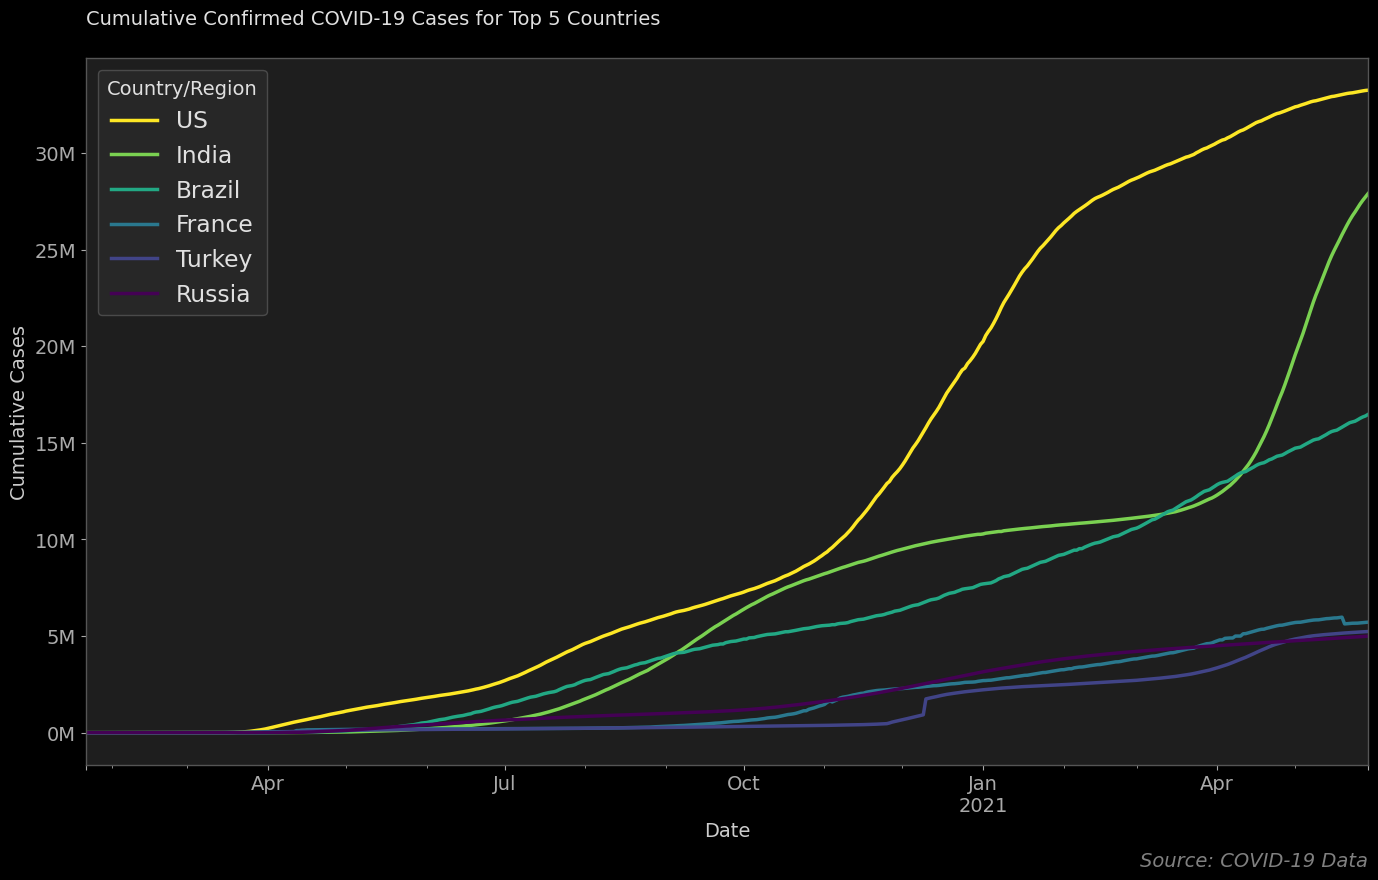

In [ ]:
def plot_top_n_countries(n):

  fig, ax = plt.subplots()
  colors = plt.cm.get_cmap('viridis_r', n).colors
  ax.set_prop_cycle(plt.cycler(color=colors))
  top_n_countries.iloc[:, :n].plot(kind='line', ax=ax, linewidth=2.5)

  ax.text(ax.get_xlim()[0], ax.get_ylim()[1]*1.05, 'Cumulative Confirmed COVID-19 Cases for Top 5 Countries', fontsize=14)
  ax.yaxis.set_major_formatter(FuncFormatter(millions_formatter))
  ax.set_xlabel('Date')
  ax.set_ylabel('Cumulative Cases')
  ax.text(ax.get_xlim()[1], ax.get_ylim()[0] - ax.get_ylim()[1]*0.15, 'Source: COVID-19 Data', ha='right', style='italic', color='grey')

  plt.tight_layout()
  plt.show()
plot_top_n_countries(6)

## **Q2.3**: Generate plots of confirmed cases over time for China.

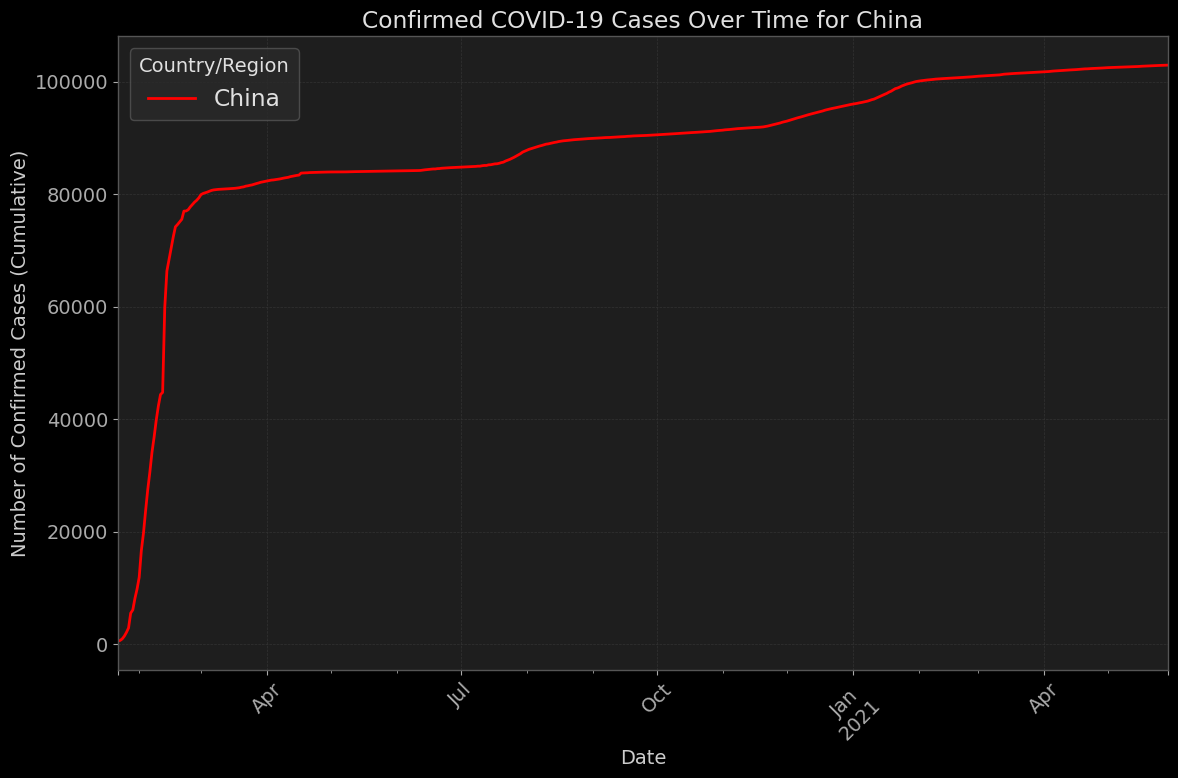

In [ ]:
plt.figure(figsize=(12,8))
top_n_countries['China'].plot(kind='line', color='red', ax=plt.gca())
plt.title('Confirmed COVID-19 Cases Over Time for China')
plt.xlabel('Date')
plt.xticks(rotation=45)
plt.ylabel('Number of Confirmed Cases (Cumulative)')
plt.legend(title='Country/Region')
plt.grid(True)
plt.tight_layout()
plt.show()




#### another way to do it - without using the top n countries that we created earlier

In [ ]:
confirmed_china = confirmed[confirmed['Country/Region'] == 'China'].drop(['Lat','Long','Province/State', 'Country/Region'], axis=1).sum().T

In [ ]:
confirmed_china.index = pd.to_datetime(confirmed_china.index)

In [ ]:
confirmed_china.head()

,0
2020-01-22,548
2020-01-23,643
2020-01-24,920
2020-01-25,1406
2020-01-26,2075


In [ ]:
# plt.figure(figsize=(12,8))
# plt.plot(confirmed_china.index,confirmed_china.values, color='red',label='China')

# plt.title('Confirmed COVID-19 Cases Over Time for China')
# plt.xlabel('Date')
# plt.xticks(rotation=45)

# plt.ylabel('Number of Confirmed Cases (Cumulative)')

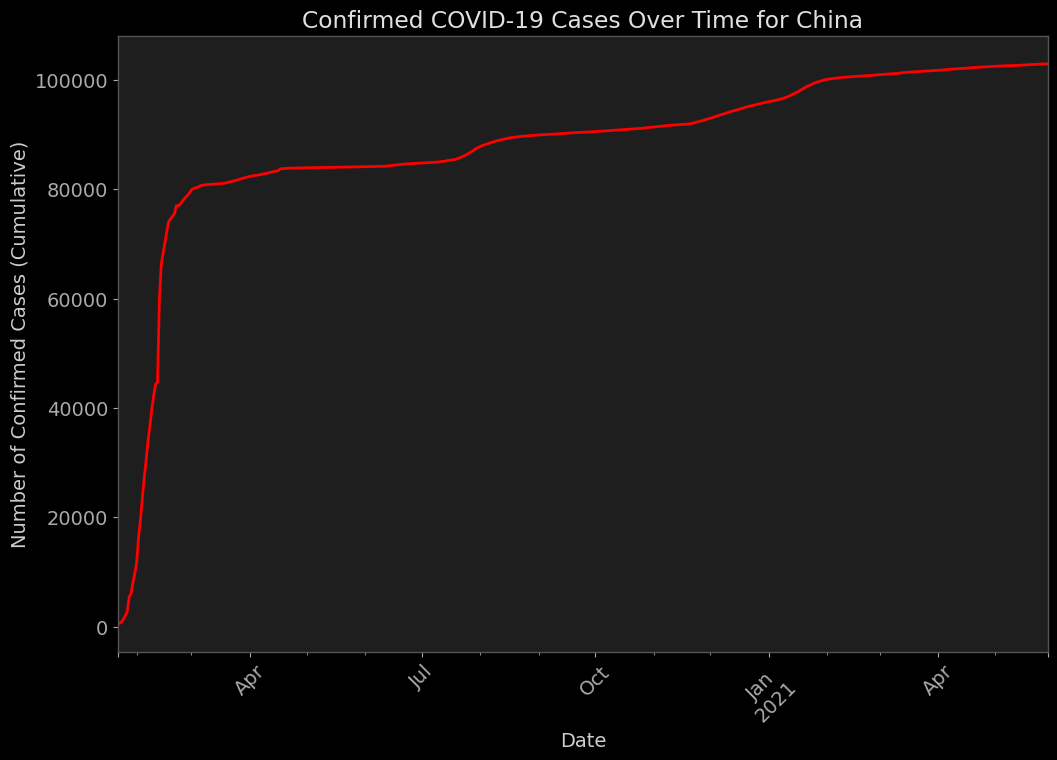

In [ ]:
plt.figure(figsize=(12,8))
confirmed_china.plot(kind='line', color='red', ax=plt.gca())

plt.title('Confirmed COVID-19 Cases Over Time for China')
plt.xlabel('Date')
plt.xticks(rotation=45)

plt.ylabel('Number of Confirmed Cases (Cumulative)')
plt.show()

# Question 3: Handling Missing Data


## **Q3.1**: Identify these missing values and replace them using a suitable imputation method, such as forward filling, for time-series data.

In [ ]:
confirmed.isna().sum()[confirmed.isna().sum() > 0]

,0
Province/State,190
Lat,2
Long,2


In [ ]:
deaths.isna().sum()[deaths.isna().sum() > 0]

,0
Province/State,190
Lat,2
Long,2
4/20/20,1


In [ ]:
recovered.isna().sum()[recovered.isna().sum()  > 0]

,0
Province/State,191
Lat,1
Long,1
4/20/20,1


In [ ]:
# confirmed['Province/State'].fillna('All Provinces', inplace=True)
# deaths['Province/State'].fillna('All Provinces', inplace=True)
# recovered['Province/State'].fillna('All Provinces', inplace=True)

# # check
# print(confirmed.isna().sum()[confirmed.isna().sum() > 0])
# print(deaths.isna().sum()[deaths.isna().sum() > 0])
# print(recovered.isna().sum()[recovered.isna().sum() > 0])


### My Analysis:

I observed `NaN` values in `Province/State`, `Lat`, `Long`, and some of the date columns.

1.  **Province/State:** I replaced `NaN` values with the string "All Provinces". This is a logical placeholder for rows that represent an entire country.
2.  **Geospatial & Time-Series Data:** For `Lat`, `Long`, and the date columns, I used the **forward-fill (`ffill`)** method. This is a standard technique for time-series data, as it presumes that a value, once reported, remains the same until a new value is reported. I applied this row-wise (`axis=1`) for the date columns, which are structured horizontally in the wide-format data.

In [ ]:
# ffill for Lat, Long
confirmed[['Lat','Long']] = confirmed[['Lat','Long']].ffill()

deaths[['Lat','Long']] = deaths[['Lat','Long']].ffill()
recovered[['Lat','Long']] = recovered[['Lat','Long']].ffill()

# ffill for dates
confirmed[confirmed.columns[4:]] = confirmed[confirmed.columns[4:]].ffill(axis=1) # since this is wide format time series data
deaths[deaths.columns[4:]] = deaths[deaths.columns[4:]].ffill(axis=1)
recovered[recovered.columns[4:]] = recovered[recovered.columns[4:]].ffill(axis=1)

# check
print(confirmed.isna().sum()[confirmed.isna().sum() > 0])
print(deaths.isna().sum()[deaths.isna().sum() > 0])
print(recovered.isna().sum()[recovered.isna().sum() > 0])


Province/State    190
dtype: int64
Province/State    190
dtype: int64
Province/State    191
dtype: int64


# Question 4: Data Cleaning and Preparation

## **Q4.1**: Replace blank values in the province column with “All Provinces.”

In [ ]:
confirmed[['Province/State']] = confirmed[['Province/State']].fillna('All Provinces')
deaths[['Province/State']] = deaths[['Province/State']].fillna('All Provinces')
recovered[['Province/State']] = recovered[['Province/State']].fillna('All Provinces')

#check
print(confirmed.isna().sum()[confirmed.isna().sum() > 0])
print(deaths.isna().sum()[deaths.isna().sum() > 0])
print(recovered.isna().sum()[recovered.isna().sum() > 0])

Series([], dtype: int64)
Series([], dtype: int64)
Series([], dtype: int64)


# Question 5: Independent Dataset Analysis

## **Q5.1**: Analyze the peak number of daily new cases in Germany, France, and Italy. Which country experienced the highest single-day surge, and when did it occur?

In [ ]:
confirmed.head()


,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,5/20/21,5/21/21,5/22/21,5/23/21,5/24/21,5/25/21,5/26/21,5/27/21,5/28/21,5/29/21
0,All Provinces,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,64575,65080,65486,65728,66275,66903,67743,68366,69130,70111
1,All Provinces,Albania,41.15330,20.168300,0,0,0,0,0,0,...,132118,132153,132176,132209,132215,132229,132244,132264,132285,132297
2,All Provinces,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,126156,126434,126651,126860,127107,127361,127646,127926,128198,128456
3,All Provinces,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,13569,13569,13569,13569,13569,13664,13671,13682,13693,13693
4,All Provinces,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,31661,31909,32149,32441,32623,32933,33338,33607,33944,34180


In [ ]:
# select only those countries and sum by province for simplicity and drop lat and long as well
selected_countries = ['Germany','France','Italy']
country_df = confirmed.groupby(['Country/Region']).sum().drop(['Lat','Long','Province/State'], axis=1)
country_df.head()
# cleaned_confirmed = confirmed[confirmed['Country/Region'].isin(['Germany','France','Italy'])].groupby(['Country/Region']).sum().drop(['Lat','Long','Province/State'], axis=1)

# cleaned_confirmed = confirmed.groupby(['Country/Region']).sum().drop(['Lat','Long','Province/State'], axis=1)
# cleaned_confirmed

,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,1/29/20,1/30/20,1/31/20,...,5/20/21,5/21/21,5/22/21,5/23/21,5/24/21,5/25/21,5/26/21,5/27/21,5/28/21,5/29/21
Country/Region,,,,,,,,,,,,,,,,,,,,,
Afghanistan,0,0,0,0,0,0,0,0,0,0,...,64575,65080,65486,65728,66275,66903,67743,68366,69130,70111
Albania,0,0,0,0,0,0,0,0,0,0,...,132118,132153,132176,132209,132215,132229,132244,132264,132285,132297
Algeria,0,0,0,0,0,0,0,0,0,0,...,126156,126434,126651,126860,127107,127361,127646,127926,128198,128456
Andorra,0,0,0,0,0,0,0,0,0,0,...,13569,13569,13569,13569,13569,13664,13671,13682,13693,13693
Angola,0,0,0,0,0,0,0,0,0,0,...,31661,31909,32149,32441,32623,32933,33338,33607,33944,34180


In [ ]:
date_cols = country_df.columns

### My Analysis:

The raw data shows cumulative cases, but to find the peak surge, we need to calculate the number of *new* cases per day. I achieved this by using the `.diff()` method along the time axis ( axis = 1 ). After calculating the daily new cases for all countries, I identified the maximum value for Germany, France, and Italy. The results show that France experienced the highest single-day surge among the three.

> more context regarding the diff method and how it works:
At its heart, the .diff() method is designed to answer a simple question: 'What is the change between the current value and the previous one?'
It calculates the difference between an element in a DataFrame or Series and the element that comes immediately before it. This makes it the perfect tool for converting a cumulative series into a periodic change series.


Imagine you have a simple list of cumulative daily cases for one week:"

| Day | Cumulative Cases |
| :-- | :--- |
| Mon | 100 |
| Tue | 120 |
| Wed | 150 |
| Thu | 155 |

"If we apply `.diff()` to the 'Cumulative Cases' column, we are asking: 'How many *new* cases were there each day?'

*   For Tuesday, the calculation is `120 (current) - 100 (previous) = 20`.
*   For Wednesday, it's `150 (current) - 120 (previous) = 30`.
*   For Thursday, it's `155 (current) - 150 (previous) = 5`.

For Monday, there is no previous day in our data, so pandas returns a `NaN` (Not a Number)."

The result would look like this:

| Day | Daily New Cases (`.diff()`) |
| :-- | :--- |
| Mon | `NaN` |
| Tue | 20 |
| Wed | 30 |
| Thu | 5 |

This is why you almost always see `.diff()` followed by `.fillna(0)` in this context—to replace that initial `NaN` with a zero, since there were no *new* cases before the first day of reporting.

Now, in our project, the data was in a **wide format**, where the time series wasn't in a single column but spread out horizontally across multiple columns, with each column representing a day.

It looked like this:

| Country/Region | `1/22/20` | `1/23/20` | `1/24/20` |
| :--- | :--- | :--- | :--- |
| **France** | 0 | 2 | 3 |
| **Germany** | 0 | 0 | 1 |

By default, `.diff()` works vertically down a column (`axis=0`). If we used it here, it would calculate `Germany - France`, which is meaningless.

To solve this, I used the parameter **`axis=1`**. This tells pandas to perform the difference calculation **horizontally, across the rows**.

So, for France, the calculation becomes:
*   `diff('1/23/20') = 2 (current) - 0 (previous) = 2`
*   `diff('1/24/20') = 3 (current) - 2 (previous) = 1`

This correctly gives us the daily new cases for each country.

In [ ]:
daily_new_cases_df = country_df.diff(axis=1)

daily_new_cases_df.head()

,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,1/29/20,1/30/20,1/31/20,...,5/20/21,5/21/21,5/22/21,5/23/21,5/24/21,5/25/21,5/26/21,5/27/21,5/28/21,5/29/21
Country/Region,,,,,,,,,,,,,,,,,,,,,
Afghanistan,NaN,0,0,0,0,0,0,0,0,0,...,453,505,406,242,547,628,840,623,764,981
Albania,NaN,0,0,0,0,0,0,0,0,0,...,23,35,23,33,6,14,15,20,21,12
Algeria,NaN,0,0,0,0,0,0,0,0,0,...,260,278,217,209,247,254,285,280,272,258
Andorra,NaN,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,95,7,11,11,0
Angola,NaN,0,0,0,0,0,0,0,0,0,...,223,248,240,292,182,310,405,269,337,236


Since the diff method returns NaN for the first value, we replace it with the actual number of cases that were reported on the first day

In [ ]:
daily_new_cases_df.iloc[:,0] = country_df.iloc[:, 0]
daily_new_cases_df['1/22/20'] = daily_new_cases_df['1/22/20'].astype('Int64')

In [ ]:
daily_new_cases_df.head()

,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,1/29/20,1/30/20,1/31/20,...,5/20/21,5/21/21,5/22/21,5/23/21,5/24/21,5/25/21,5/26/21,5/27/21,5/28/21,5/29/21
Country/Region,,,,,,,,,,,,,,,,,,,,,
Afghanistan,0,0,0,0,0,0,0,0,0,0,...,453,505,406,242,547,628,840,623,764,981
Albania,0,0,0,0,0,0,0,0,0,0,...,23,35,23,33,6,14,15,20,21,12
Algeria,0,0,0,0,0,0,0,0,0,0,...,260,278,217,209,247,254,285,280,272,258
Andorra,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,95,7,11,11,0
Angola,0,0,0,0,0,0,0,0,0,0,...,223,248,240,292,182,310,405,269,337,236


In [ ]:
peak_daily_cases_df = daily_new_cases_df.max(axis=1)

peak_daily_cases_df.head()

,0
Country/Region,
Afghanistan,1485
Albania,1239
Algeria,1133
Andorra,299
Angola,405


In [ ]:
peak_daily_cases_df.loc[selected_countries]

,0
Country/Region,
Germany,49044
France,117900
Italy,40902


In [ ]:
# #  manually calculating the daily new cases
# for column in daily_cases_df.columns:
#   current_series = daily_cases_df[column]
#   # print(current_series[:5])
#   # print(len(current_series))
#   n = len(current_series)
#   for i in range(1,n):
#     current_value = current_series.iloc[i]
#     previous_value = current_series.iloc[i-1]
#     current_series.iloc[i] = current_value - previous_value
#   daily_cases_df[column] = current_series
# daily_cases_df.head(10)

In [ ]:
# peak case per country
for country in peak_daily_cases_df[selected_countries].index:
  print(f"{country} : {peak_daily_cases_df[country].max()}")

Germany : 49044
France : 117900
Italy : 40902


In [ ]:
peak_daily_cases_df[selected_countries].idxmax(), peak_daily_cases_df[selected_countries].max()

('France', np.int64(117900))

In [ ]:
# date of the max cases
daily_new_cases_df.loc[peak_daily_cases_df[selected_countries].idxmax(),:].idxmax()

'4/11/21'

In [ ]:
print(f"The country with the highest single-day surge is {peak_daily_cases_df[selected_countries].idxmax()} with {peak_daily_cases_df[selected_countries].max()} cases on {daily_new_cases_df.loc[peak_daily_cases_df[selected_countries].idxmax(),:].idxmax()}")

The country with the highest single-day surge is France with 117900 cases on 4/11/21


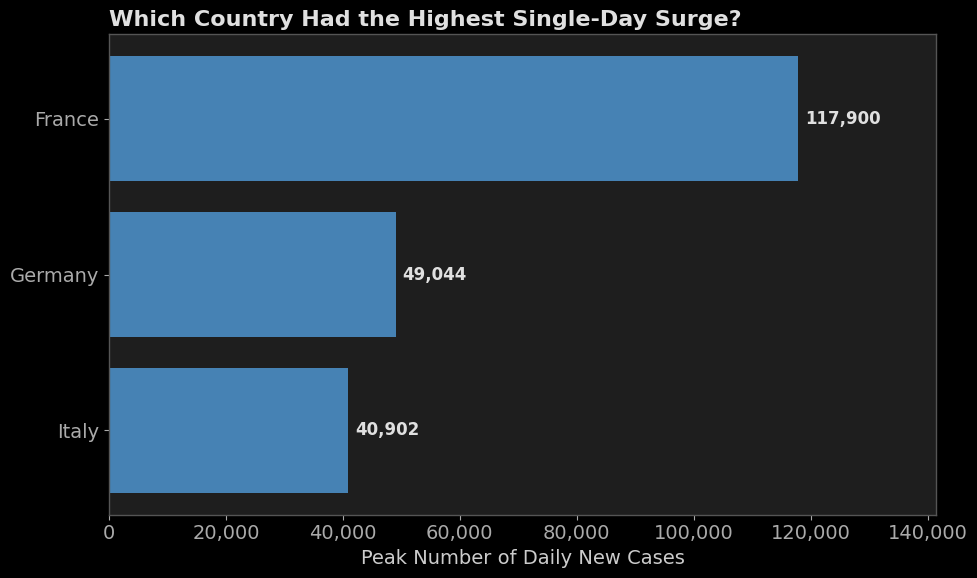

In [ ]:
fig_q5_1, ax_q5_1 = plt.subplots(figsize=(10, 6))

plot_data = peak_daily_cases_df.loc[selected_countries].sort_values(ascending=True)
bars = ax_q5_1.barh(plot_data.index, plot_data.values, color='steelblue')
ax_q5_1.set_title('Which Country Had the Highest Single-Day Surge?', loc='left', fontsize=16, fontweight='bold')
ax_q5_1.set_xlabel('Peak Number of Daily New Cases')
ax_q5_1.set_ylabel('')
ax_q5_1.bar_label(bars, fmt='{:,.0f}', padding=5, fontsize=12, fontweight='bold')
ax_q5_1.xaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x:,.0f}'))
ax_q5_1.set_xlim(right=plot_data.max() * 1.2)

plt.tight_layout()
plt.show()

In [ ]:
# fig_q5_1, ax_q5_1 = plt.subplots(figsize=(8, 6))
# peak_daily_cases_df.loc[selected_countries].sort_values(ascending=False).plot(kind='bar', ax=ax_q5_1)
# ax_q5_1.set_title('Peak Daily New Cases')
# ax_q5_1.set_xlabel('Country')
# ax_q5_1.set_ylabel('Peak Number of Daily New Cases')
# plt.xticks(rotation=45, ha='right')
# plt.tight_layout()

## Q5.2: "Compare the recovery rates (recoveries/confirmed cases) between Canada and Australia as of December 31, 2020. Which country showed better management of the pandemic according to this metric?"

#### My analysis:
I calculated the **recovery rate**, which I defined as the total number of recovered cases divided by the total number of confirmed cases. This metric provides a snapshot of the proportion of diagnosed individuals who have recovered.

The analysis required aggregating cumulative totals for both confirmed and recovered cases for each country and then calculating the ratio for that specific date.

In [ ]:
date_to_compare = '12/31/20'
country_df[country_df.index.isin(['Canada','Australia'])]

,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,1/29/20,1/30/20,1/31/20,...,5/20/21,5/21/21,5/22/21,5/23/21,5/24/21,5/25/21,5/26/21,5/27/21,5/28/21,5/29/21
Country/Region,,,,,,,,,,,,,,,,,,,,,
Australia,0,0,0,0,4,5,5,6,9,9,...,29999,30003,30007,30019,30029,30046,30063,30074,30083,30096
Canada,0,0,0,0,1,1,2,2,2,4,...,1355733,1360264,1363519,1366475,1368241,1371941,1374272,1378993,1382107,1384373


In [ ]:
recovered.head()

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,5/20/21,5/21/21,5/22/21,5/23/21,5/24/21,5/25/21,5/26/21,5/27/21,5/28/21,5/29/21
0,All Provinces,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,55687,55790,55889,56035,56295,56518,56711,56962,57119,57281
1,All Provinces,Albania,41.15330,20.168300,0,0,0,0,0,0,...,127869,128425,128601,128732,128826,128907,128978,129042,129097,129215
2,All Provinces,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,87902,88066,88208,88346,88497,88672,88861,89040,89232,89419
3,All Provinces,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,13234,13234,13234,13234,13234,13263,13381,13405,13416,13416
4,All Provinces,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,26483,26513,26775,26778,27087,27204,27467,27529,27577,27646


In [ ]:
country_df_recovered = recovered.drop(['Lat','Long','Province/State'], axis=1).groupby('Country/Region').sum()
country_df_recovered.head()

,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,1/29/20,1/30/20,1/31/20,...,5/20/21,5/21/21,5/22/21,5/23/21,5/24/21,5/25/21,5/26/21,5/27/21,5/28/21,5/29/21
Country/Region,,,,,,,,,,,,,,,,,,,,,
Afghanistan,0,0,0,0,0,0,0,0,0,0,...,55687,55790,55889,56035,56295,56518,56711,56962,57119,57281
Albania,0,0,0,0,0,0,0,0,0,0,...,127869,128425,128601,128732,128826,128907,128978,129042,129097,129215
Algeria,0,0,0,0,0,0,0,0,0,0,...,87902,88066,88208,88346,88497,88672,88861,89040,89232,89419
Andorra,0,0,0,0,0,0,0,0,0,0,...,13234,13234,13234,13234,13234,13263,13381,13405,13416,13416
Angola,0,0,0,0,0,0,0,0,0,0,...,26483,26513,26775,26778,27087,27204,27467,27529,27577,27646


In [ ]:
country_df.columns

Index(['1/22/20', '1/23/20', '1/24/20', '1/25/20', '1/26/20', '1/27/20',
       '1/28/20', '1/29/20', '1/30/20', '1/31/20',
       ...
       '5/20/21', '5/21/21', '5/22/21', '5/23/21', '5/24/21', '5/25/21',
       '5/26/21', '5/27/21', '5/28/21', '5/29/21'],
      dtype='object', length=494)

In [ ]:
country_df_recovered.columns

Index(['1/22/20', '1/23/20', '1/24/20', '1/25/20', '1/26/20', '1/27/20',
       '1/28/20', '1/29/20', '1/30/20', '1/31/20',
       ...
       '5/20/21', '5/21/21', '5/22/21', '5/23/21', '5/24/21', '5/25/21',
       '5/26/21', '5/27/21', '5/28/21', '5/29/21'],
      dtype='object', length=494)

double-checking if the two dataframes align perfectly


In [ ]:
pd.Series(country_df.columns == country_df_recovered.columns).value_counts()

,count
True,494


In [ ]:
pd.Series(country_df.index == country_df_recovered.index).value_counts()

,count
True,193


In [ ]:
recovery_rate_df = country_df_recovered.div(country_df)
recovery_rate_df.head()

,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,1/29/20,1/30/20,1/31/20,...,5/20/21,5/21/21,5/22/21,5/23/21,5/24/21,5/25/21,5/26/21,5/27/21,5/28/21,5/29/21
Country/Region,,,,,,,,,,,,,,,,,,,,,
Afghanistan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.862362,0.857253,0.85345,0.852529,0.849415,0.844775,0.837149,0.833192,0.826255,0.817004
Albania,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.967839,0.97179,0.972953,0.973701,0.974368,0.974877,0.975303,0.97564,0.975901,0.976704
Algeria,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.696772,0.696537,0.696465,0.696405,0.69624,0.696226,0.696152,0.696027,0.696048,0.696106
Andorra,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.975311,0.975311,0.975311,0.975311,0.975311,0.970653,0.978787,0.979754,0.979771,0.979771
Angola,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.836455,0.830894,0.832841,0.825437,0.830304,0.826041,0.823895,0.819145,0.812426,0.808836


In [ ]:
recovery_rate_df.loc[['Canada','Australia'], ['12/31/20']]

,12/31/20
Country/Region,
Canada,0.844679
Australia,0.793843


In [ ]:
print(f"{recovery_rate_df.loc[['Canada','Australia'], ['12/31/20']].idxmax().iloc[0]} managed the pandemic better as of 12/31/20 due to recovery rate of {recovery_rate_df.loc[['Canada','Australia'], ['12/31/20']].max().iloc[0] * 100} %")

Canada managed the pandemic better as of 12/31/20 due to recovery rate of 84.46789833832128 %


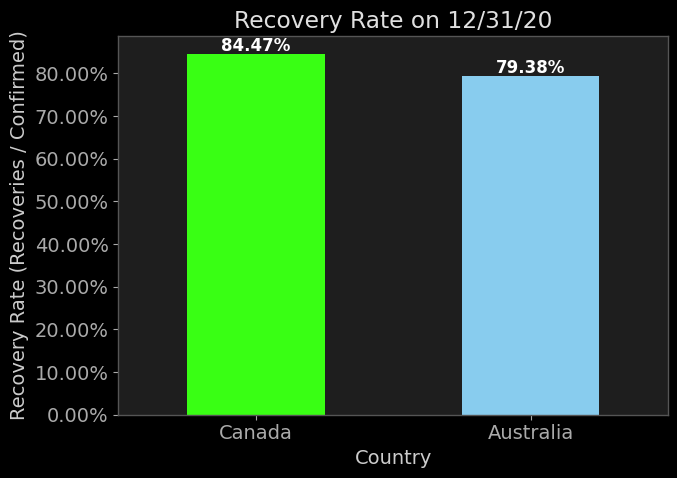

In [ ]:
result_series_q5_2 = recovery_rate_df.loc[['Canada', 'Australia'], [date_to_compare]].iloc[:,0]
neon_green_color = '#39FF14'
default_bar_color = '#88CCEE'
highest_rate_country = result_series_q5_2.idxmax()
bar_colors = [neon_green_color if country == highest_rate_country else default_bar_color for country in result_series_q5_2.index]
fig_q5_2, ax_q5_2 = plt.subplots(figsize=(7, 5))
bars = result_series_q5_2.plot(kind='bar', ax=ax_q5_2,color=bar_colors)
text_padding = 0.008 # Slightly reduced padding for a tighter fit
for i, bar in enumerate(bars.patches): # Access patches from the result of .plot()
    text_color_for_bar = 'white'

    ax_q5_2.text(bar.get_x() + bar.get_width() / 2, # X-position: center of bar
                 bar.get_height() + 0.04,    # Y-position: slightly below top edge of bar
                 f'{result_series_q5_2.values[i]:.2%}',
                 ha='center', va='top',              # Vertical alignment: top (text top aligns to y-coord)
                 fontsize=12, color=text_color_for_bar,
                 fontweight='bold')
ax_q5_2.set_title(f'Recovery Rate on {date_to_compare}')
ax_q5_2.set_ylabel('Recovery Rate (Recoveries / Confirmed)')
ax_q5_2.set_xlabel('Country')
ax_q5_2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '{:.2%}'.format(x)))
plt.xticks(rotation=0)
plt.tight_layout()

In [ ]:
pd.Series(confirmed['Country/Region'].unique() == recovered['Country/Region'].unique()).value_counts()

,count
True,193


## **Q5.3**: What is the distribution of death rates (deaths/confirmed cases) among provinces in Canada? Identify the province with the highest and lowest death rate as of the latest data point.


In [ ]:
confirmed_Canada = confirmed[confirmed['Country/Region'] == 'Canada'].drop(['Country/Region','Lat','Long'], axis=1).set_index('Province/State')
confirmed_Canada.head()

,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,1/29/20,1/30/20,1/31/20,...,5/20/21,5/21/21,5/22/21,5/23/21,5/24/21,5/25/21,5/26/21,5/27/21,5/28/21,5/29/21
Province/State,,,,,,,,,,,,,,,,,,,,,
Alberta,0,0,0,0,0,0,0,0,0,0,...,222279,223011,223632,224195,224647,225034,225424,225937,226449,226855
British Columbia,0,0,0,0,0,0,1,1,1,1,...,140953,141373,141373,141373,141373,142636,142886,143264,143581,143581
Diamond Princess,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Grand Princess,0,0,0,0,0,0,0,0,0,0,...,13,13,13,13,13,13,13,13,13,13
Manitoba,0,0,0,0,0,0,0,0,0,0,...,46916,47504,47977,48436,48787,49046,49356,49651,50144,50499


In [ ]:
confirmed_Canada.columns[-1]

'5/29/21'

In [ ]:
deaths_Canada = deaths[deaths['Country/Region'] == 'Canada'].drop(['Country/Region','Lat','Long'], axis=1).set_index('Province/State')
deaths_Canada.head()

,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,1/29/20,1/30/20,1/31/20,...,5/20/21,5/21/21,5/22/21,5/23/21,5/24/21,5/25/21,5/26/21,5/27/21,5/28/21,5/29/21
Province/State,,,,,,,,,,,,,,,,,,,,,
Alberta,0,0,0,0,0,0,0,0,0,0,...,2162,2164,2170,2176,2183,2192,2198,2199,2206,2214
British Columbia,0,0,0,0,0,0,0,0,0,0,...,1661,1667,1667,1667,1667,1680,1683,1690,1692,1692
Diamond Princess,0,0,0,0,0,0,0,0,0,0,...,1,1,1,1,1,1,1,1,1,1
Grand Princess,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Manitoba,0,0,0,0,0,0,0,0,0,0,...,1019,1022,1028,1029,1033,1035,1035,1042,1042,1045


In [ ]:
deaths_Canada.columns[-1]

'5/29/21'

In [ ]:
death_rate_canada_df = deaths_Canada.div(confirmed_Canada)

death_rate_canada_df.head()

,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,1/29/20,1/30/20,1/31/20,...,5/20/21,5/21/21,5/22/21,5/23/21,5/24/21,5/25/21,5/26/21,5/27/21,5/28/21,5/29/21
Province/State,,,,,,,,,,,,,,,,,,,,,
Alberta,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.009727,0.009704,0.009703,0.009706,0.009717,0.009741,0.009751,0.009733,0.009742,0.00976
British Columbia,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,...,0.011784,0.011792,0.011792,0.011792,0.011792,0.011778,0.011779,0.011796,0.011784,0.011784
Diamond Princess,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf
Grand Princess,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Manitoba,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.02172,0.021514,0.021427,0.021245,0.021174,0.021103,0.02097,0.020986,0.02078,0.020693


#### the latest data point would be the last date column

In [ ]:
death_rate_canada_df[deaths_Canada.columns[-1]]

,5/29/21
Province/State,
Alberta,0.00976
British Columbia,0.011784
Diamond Princess,inf
Grand Princess,0.0
Manitoba,0.020693
New Brunswick,0.019626
Newfoundland and Labrador,0.004608
Northwest Territories,0.0
Nova Scotia,0.01519


minor data cleaning - replacing the inf values ( since in some cases there was data in deaths  but not in confirmed dataset )

In [ ]:
death_rate_canada_df['5/29/21'].replace(np.inf, np.nan, inplace=True)
death_rate_canada_df[deaths_Canada.columns[-1]]

,5/29/21
Province/State,
Alberta,0.00976
British Columbia,0.011784
Diamond Princess,<NA>
Grand Princess,0.0
Manitoba,0.020693
New Brunswick,0.019626
Newfoundland and Labrador,0.004608
Northwest Territories,0.0
Nova Scotia,0.01519


In [ ]:
deaths_Canada.index

Index(['Alberta', 'British Columbia', 'Diamond Princess', 'Grand Princess',
       'Manitoba', 'New Brunswick', 'Newfoundland and Labrador',
       'Northwest Territories', 'Nova Scotia', 'Nunavut', 'Ontario',
       'Prince Edward Island', 'Quebec', 'Repatriated Travellers',
       'Saskatchewan', 'Yukon'],
      dtype='object', name='Province/State')

In [ ]:
print(f"Province with highest death rate : {death_rate_canada_df[deaths_Canada.columns[-1]].idxmax()}, with a death rate of {death_rate_canada_df[deaths_Canada.columns[-1]].max():.2%}")
print(f"Province with lowest death rate : {death_rate_canada_df[deaths_Canada.columns[-1]].idxmin()}, with a death rate of {death_rate_canada_df[deaths_Canada.columns[-1]].min():.2%}")

Province with highest death rate : Quebec, with a death rate of 3.01%
Province with lowest death rate : Grand Princess, with a death rate of 0.00%


#### My analysis:

During this analysis, I had to handle an important data anomaly: entries like 'Grand Princess', 'Diamond Princess' and 'Repatriated Travellers' are not geographical provinces and were excluded from the final comparison of provincial rates.

In [ ]:
# However,  from google search it seems like Diamond Princess, Grand Princess are  not provinces, and Repatriated Travellers does not make sense either

print(f"Province with highest death rate : {death_rate_canada_df[deaths_Canada.columns[-1]].drop(['Grand Princess','Diamond Princess','Repatriated Travellers']).idxmax()}, with a death rate of {death_rate_canada_df[deaths_Canada.columns[-1]].max():.2%}")
print(f"Province with lowest death rate : {death_rate_canada_df[deaths_Canada.columns[-1]].drop(['Grand Princess','Diamond Princess','Repatriated Travellers']).idxmin()}, with a death rate of {death_rate_canada_df[deaths_Canada.columns[-1]].min():.2%}")


Province with highest death rate : Quebec, with a death rate of 3.01%
Province with lowest death rate : Northwest Territories, with a death rate of 0.00%


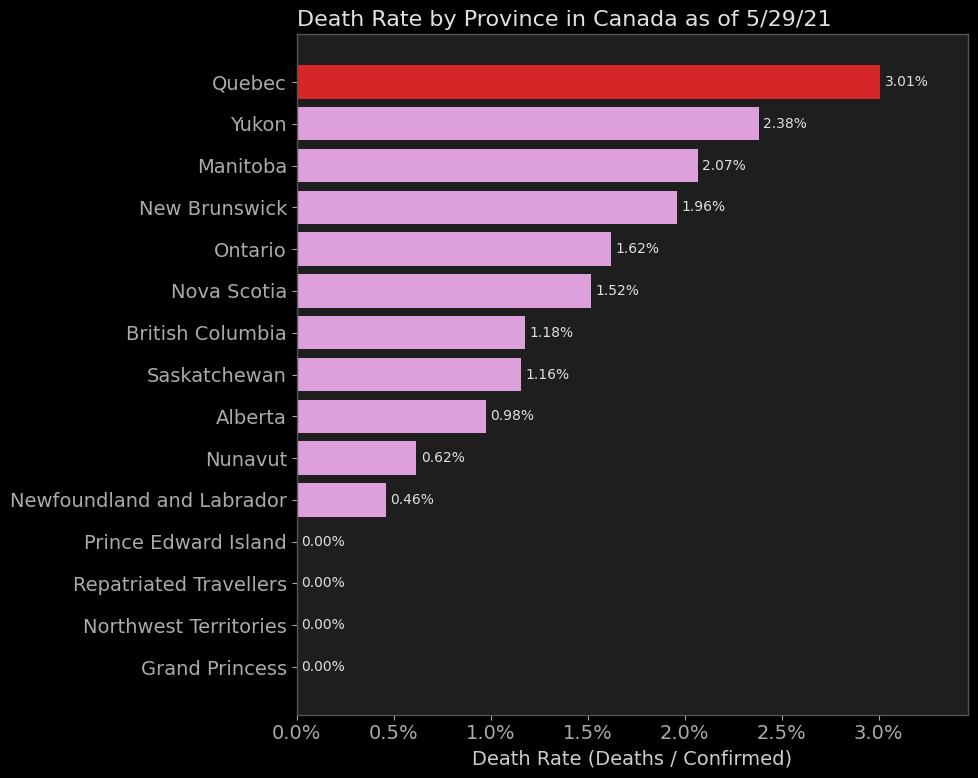

In [ ]:
fig_q5_3, ax_q5_3 = plt.subplots(figsize=(10, 8))

latest_rates_q5_3 = death_rate_canada_df[deaths_Canada.columns[-1]].replace(np.inf, np.nan).dropna().sort_values(ascending=True)
latest_rates_pct = latest_rates_q5_3 * 100 # Convert to percentage for labeling

highest_province = latest_rates_q5_3.drop(['Grand Princess', 'Diamond Princess', 'Repatriated Travellers'], errors='ignore').idxmax()
lowest_province = latest_rates_q5_3.drop(['Grand Princess', 'Diamond Princess', 'Repatriated Travellers'], errors='ignore').idxmin()

colors = ['#d62728' if x == highest_province else '#2ca02c' if x == lowest_province else 'plum' for x in latest_rates_q5_3.index]

bars = ax_q5_3.barh(latest_rates_pct.index, latest_rates_pct.values, color=colors)

ax_q5_3.set_title(f"Death Rate by Province in Canada as of {deaths_Canada.columns[-1]}", loc='left', fontsize=16)
ax_q5_3.set_xlabel("Death Rate (Deaths / Confirmed)")
ax_q5_3.set_ylabel("")

ax_q5_3.bar_label(bars, fmt='%.2f%%', padding=3, fontsize=10)

ax_q5_3.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}%'))
ax_q5_3.set_xlim(right=latest_rates_pct.max() * 1.15)

plt.tight_layout()
plt.show()

In [ ]:
# latest_rates_q5_3 = death_rate_canada_df[deaths_Canada.columns[-1]].replace(np.inf, np.nan).dropna() # Renaming

# fig_q5_3, ax_q5_3 = plt.subplots(figsize=(10, 8))
# latest_rates_q5_3.sort_values().plot(kind='barh', ax=ax_q5_3)
# ax_q5_3.set_title(f"Death Rates in Canadian Provinces as of {deaths_Canada.columns[-1]}")
# ax_q5_3.set_xlabel("Death Rate (Deaths / Confirmed)")
# ax_q5_3.set_ylabel("Province")
# ax_q5_3.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '{:.2%}'.format(x)))
# plt.tight_layout()

# Question 6: Data Transformation.

## Q6.1: "Transform the 'deaths' dataset from wide format (where each column represents a date) to long format, where each row represents a single date, ensuring that the date column is in datetime format. How would this transformation be executed?"


#### explanation and analysis on long vs wide format data -


As you can see here, each row represents a geographical location (like a country or province), but the time-series information—the daily case counts—is spread out across hundreds of columns, one for each date."


| Country/Region | Province/State | ... | `1/22/20` | `1/23/20` | `1/24/20` |
| :--- | :--- | :-: | :--- | :--- | :--- |
| **Australia** | New South Wales | ... | 0 | 0 | 0 |
| **Australia** | Victoria | ... | 0 | 1 | 1 |

This format is intuitive for human eyes, like a spreadsheet, but it's very inefficient for computational analysis for several key reasons:

1.  **Difficulty in Aggregation:** If I want to find the total deaths in the month of May, I would have to manually select all 31 'May' columns and sum them up. This is cumbersome and not scalable.
2.  **Merging is Impossible:** My three datasets—confirmed, deaths, and recoveries—are separate. To create a single, unified view of the pandemic for a given country on a given day, I need a common 'Date' column to merge on. In the wide format, there is no single 'Date' column.
3.  **Plotting Limitations:** Most plotting libraries, especially for advanced time-series analysis, expect time to be a single variable (a column), not spread across the entire DataFrame.

To solve these problems, I needed to transform the data into a **'long' format**.

---

The goal was to reshape the data so that **each row represents a single observation for one location on one date**.

The target 'long' format looks like this:"

| Country/Region | Province/State | Date | Deaths |
| :--- | :--- | :--- | :--- |
| Australia | New South Wales| `2020-01-22` | 0 |
| Australia | New South Wales| `2020-01-23` | 0 |
| ... | ... | ... | ... |
| Australia | Victoria | `2020-01-22` | 0 |
| Australia | Victoria | `2020-01-23` | 1 |

Notice the key changes:
*   We now have a dedicated **'Date'** column.
*   We have a dedicated **'Deaths'** column containing the values.
*   The original date columns have been 'unpivoted' or 'melted' into these two new columns.

This structure, often called 'tidy data', is the standard for data analysis in pandas and other systems. It directly enables powerful operations like `groupby()`, `merge()`, and time-series plotting.

---


"To perform this transformation efficiently, I used the powerful `pandas.melt()` function. Here's how it works conceptually: `melt` takes a wide DataFrame and 'unpivots' it.

You need to tell `melt` three things:

1.  **`id_vars` (The Identifier Columns):** Which columns should remain as they are? These are the columns that identify each row. In our case, this was `['Country/Region', 'Province/State', 'Lat', 'Long']`. These columns anchor the data.

2.  **`value_vars` (The Columns to Unpivot):** Which columns should be 'melted' down into a single new column? These were all the date columns. If you don't specify this, pandas cleverly assumes you mean 'all other columns not in `id_vars`'.

3.  **`var_name` and `value_name` (The New Column Names):** What should we name the two new columns that will be created?
    *   `var_name='Date'` creates the new column holding the former column headers (e.g., '1/22/20').
    *   `value_name='Deaths'` creates the new column holding the actual data values.



After running this for all three datasets, I had clean, long-format DataFrames ready for the final, more complex stages of analysis, such as merging and monthly aggregations.

In [ ]:
# we will use pandas melt function for this

# we need id_vars or cols whose values will remain same for changed dates
# we need value_vars as the columns who will be now converted into values -> if not given explicitly, remaining columns will be taken by default
# var_name -> new column with the date value
# value_name -> new column with the counts


confirmed_long = pd.melt(frame=confirmed, id_vars=['Country/Region','Province/State','Lat','Long'],var_name='Date', value_name='Counts')

confirmed_long.head()

,Country/Region,Province/State,Lat,Long,Date,Counts
0,Afghanistan,All Provinces,33.93911,67.709953,1/22/20,0
1,Albania,All Provinces,41.15330,20.168300,1/22/20,0
2,Algeria,All Provinces,28.03390,1.659600,1/22/20,0
3,Andorra,All Provinces,42.50630,1.521800,1/22/20,0
4,Angola,All Provinces,-11.20270,17.873900,1/22/20,0


In [ ]:
deaths_long = pd.melt(frame=deaths, id_vars=['Country/Region','Province/State','Lat','Long'],var_name='Date', value_name='Counts')

In [ ]:
recovered_long = pd.melt(frame=recovered, id_vars=['Country/Region','Province/State','Lat','Long'],var_name='Date', value_name='Counts')

In [ ]:
deaths_long[deaths_long['Country/Region'] == 'India'].tail()

,Country/Region,Province/State,Lat,Long,Date,Counts
135111,India,All Provinces,20.593684,78.96288,5/25/21,311388
135387,India,All Provinces,20.593684,78.96288,5/26/21,315235
135663,India,All Provinces,20.593684,78.96288,5/27/21,318895
135939,India,All Provinces,20.593684,78.96288,5/28/21,322512
136215,India,All Provinces,20.593684,78.96288,5/29/21,325972


In [ ]:
recovered_long[recovered_long['Country/Region'] == 'India'].tail()

,Country/Region,Province/State,Lat,Long,Date,Counts
127761,India,All Provinces,20.593684,78.96288,5/25/21,24350816
128022,India,All Provinces,20.593684,78.96288,5/26/21,24633951
128283,India,All Provinces,20.593684,78.96288,5/27/21,24893410
128544,India,All Provinces,20.593684,78.96288,5/28/21,25178011
128805,India,All Provinces,20.593684,78.96288,5/29/21,25454320


In [ ]:
confirmed_long['Date'] = pd.to_datetime(confirmed_long['Date'])
deaths_long['Date'] = pd.to_datetime(deaths_long['Date'])
recovered_long['Date'] = pd.to_datetime(recovered_long['Date'])

confirmed_long.info()
deaths_long.info()
recovered_long.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136344 entries, 0 to 136343
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   Country/Region  136344 non-null  object        
 1   Province/State  136344 non-null  object        
 2   Lat             136344 non-null  float64       
 3   Long            136344 non-null  float64       
 4   Date            136344 non-null  datetime64[ns]
 5   Counts          136344 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(1), object(2)
memory usage: 6.2+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136344 entries, 0 to 136343
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   Country/Region  136344 non-null  object        
 1   Province/State  136344 non-null  object        
 2   Lat             136344 non-null  float64       
 3   Long 

## Q6.2: "What is the total number of deaths reported per country up to the current date?"

Now that our 'deaths' data is in a long format, answering questions about totals becomes incredibly simple. To find the total number of deaths for each country up to the latest date, the process is:

1.  **Filter for the Latest Date:** First, I needed to isolate the data for only the most recent day in the dataset. This gives me the final cumulative count for every location. I did this by finding the maximum date in the 'Date' column and filtering the DataFrame.
    
2.  **Group and Sum:** With only the latest data remaining, I used `groupby('Country/Region')` and then summed the 'Deaths' column. This collapses all the province-level data into a single, total figure for each country.
    
3.  **Sort and Visualize:** Finally, I sorted the results in descending order to identify the countries with the highest total deaths and visualized the top 10. The long format makes this `groupby-sum` operation trivial, whereas it would have been very complex in the wide format.

In [ ]:
deaths_long[deaths_long['Date'] == deaths_long['Date'].max()
]

,Country/Region,Province/State,Lat,Long,Date,Counts
136068,Afghanistan,All Provinces,33.939110,67.709953,2021-05-29,2899
136069,Albania,All Provinces,41.153300,20.168300,2021-05-29,2449
136070,Algeria,All Provinces,28.033900,1.659600,2021-05-29,3460
136071,Andorra,All Provinces,42.506300,1.521800,2021-05-29,127
136072,Angola,All Provinces,-11.202700,17.873900,2021-05-29,757
...,...,...,...,...,...,...
136339,Vietnam,All Provinces,14.058324,108.277199,2021-05-29,47
136340,West Bank and Gaza,All Provinces,31.952200,35.233200,2021-05-29,3492
136341,Yemen,All Provinces,15.552727,48.516388,2021-05-29,1319
136342,Zambia,All Provinces,-13.133897,27.849332,2021-05-29,1276


In [ ]:
total_deaths_sorted = deaths_long[deaths_long['Date'] == deaths_long['Date'].max()
].groupby('Country/Region')['Counts'].sum().sort_values(ascending=False)

total_deaths_sorted.head(10)

,Counts
Country/Region,
US,594306
Brazil,461057
India,325972
Mexico,223455
United Kingdom,128037
Italy,126002
Russia,118781
France,109518
Germany,88413


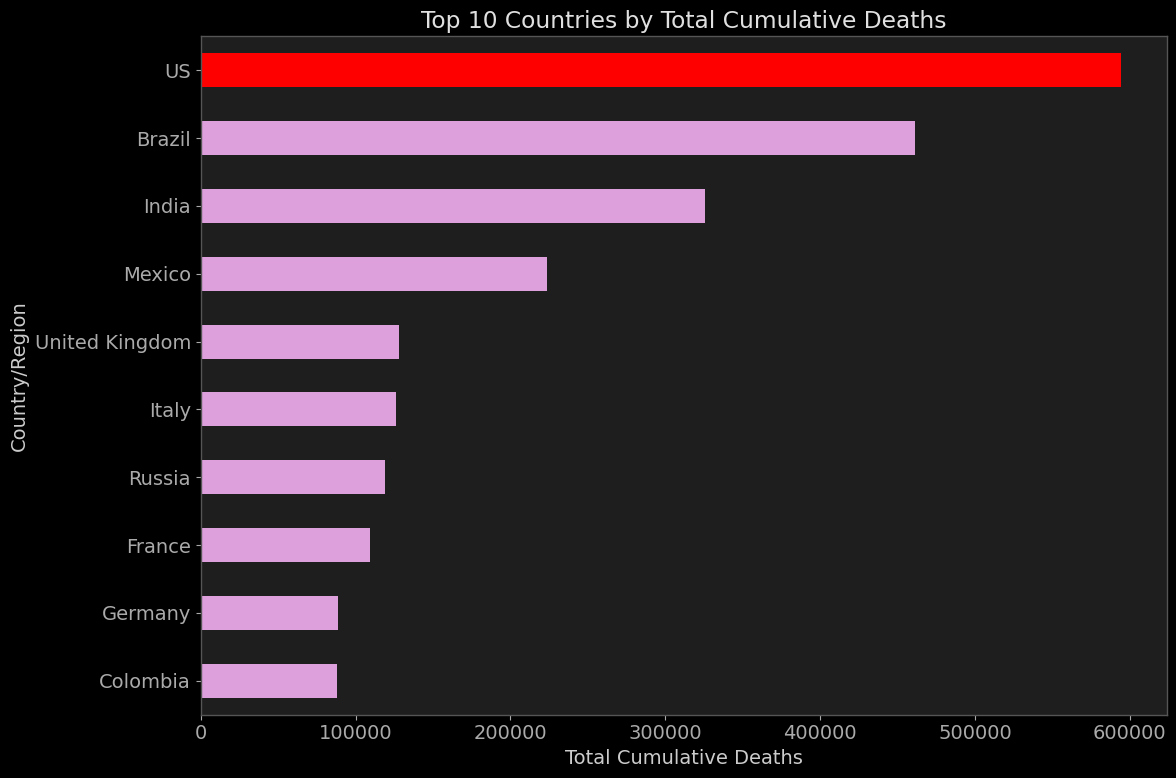

In [ ]:
top_10_countries = total_deaths_sorted.head(10).copy().sort_values(ascending=True)
fig_q6_2, ax_q6_2 = plt.subplots(figsize=(12, 8))
colors = ['red' if value == top_10_countries.max() else 'plum' for value in top_10_countries]
top_10_countries.plot(kind='barh', ax=ax_q6_2, color=colors)
ax_q6_2.set_title('Top 10 Countries by Total Cumulative Deaths')
ax_q6_2.set_xlabel('Total Cumulative Deaths')
ax_q6_2.set_ylabel('Country/Region')
plt.tight_layout()

## **Q6.3**: What are the top 5 countries with the highest average daily deaths?

In [ ]:
deaths_long.head()

,Country/Region,Province/State,Lat,Long,Date,Counts
0,Afghanistan,All Provinces,33.93911,67.709953,2020-01-22,0
1,Albania,All Provinces,41.15330,20.168300,2020-01-22,0
2,Algeria,All Provinces,28.03390,1.659600,2020-01-22,0
3,Andorra,All Provinces,42.50630,1.521800,2020-01-22,0
4,Angola,All Provinces,-11.20270,17.873900,2020-01-22,0


In [ ]:
daily_deaths_long = deaths_long.copy().reset_index()[['Country/Region','Date','Counts']]
daily_deaths_long.head()

,Country/Region,Date,Counts
0,Afghanistan,2020-01-22,0
1,Albania,2020-01-22,0
2,Algeria,2020-01-22,0
3,Andorra,2020-01-22,0
4,Angola,2020-01-22,0


#### My analysis:

This next question is more nuanced. I wasn't interested in the total deaths, but in the **average number of new deaths per day** over the entire pandemic period. This metric helps normalize for the duration of a country's outbreak and shows which nations sustained high daily death tolls.

This is a multi-step calculation that hinges on the long format:

1.  **Sort the Data:** The first, and most crucial, step is to sort the entire long DataFrame by `Country/Region` and then by `Date`. This ensures that for each country, the rows are in perfect chronological order. This is essential for the next step to work correctly.
    
2.  **Calculate Daily New Deaths:** With the data sorted, I can now use the `groupby('Country/Region')` followed by `.diff()` on the cumulative 'Deaths' column. The `groupby` operation is key here—it tells pandas to calculate the difference *within each country's data*, resetting the calculation for every new country. This prevents `.diff()` from incorrectly calculating the change from the last day of 'Brazil' to the first day of 'Canada', for example.
    
3.  **Calculate the Average:** Once I had the 'Daily_Deaths' for every country on every day, I could perform a final `groupby('Country/Region')` and apply the `.mean()` function to get the average daily figure.
    
4.  **Sort and Visualize:** Sorting this final series reveals the countries with the highest sustained daily death counts over the period.

In [ ]:
# The critical point is that for .diff() to give a meaningful "previous day's value" within each group, the data within that group must be sorted chronologically by date.

In [ ]:
# sort by country and date -> creating groups of countries

In [ ]:
daily_deaths_long_sorted = daily_deaths_long.sort_values(by=['Country/Region','Date'])
daily_deaths_long_sorted.head()

,Country/Region,Date,Counts
0,Afghanistan,2020-01-22,0
276,Afghanistan,2020-01-23,0
552,Afghanistan,2020-01-24,0
828,Afghanistan,2020-01-25,0
1104,Afghanistan,2020-01-26,0


In [ ]:
daily_deaths_long_sorted['daily_deaths'] = daily_deaths_long_sorted.groupby('Country/Region')['Counts'].diff()
daily_deaths_long_sorted['daily_deaths'] = daily_deaths_long_sorted['daily_deaths'].fillna(daily_deaths_long_sorted['Counts'])
daily_deaths_long_sorted.head()

,Country/Region,Date,Counts,daily_deaths
0,Afghanistan,2020-01-22,0,0
276,Afghanistan,2020-01-23,0,0
552,Afghanistan,2020-01-24,0,0
828,Afghanistan,2020-01-25,0,0
1104,Afghanistan,2020-01-26,0,0


In [ ]:
avg_daily_deaths = daily_deaths_long_sorted.groupby('Country/Region')['daily_deaths'].mean().sort_values(ascending=False)
print(f"top 5 countries with highest average daily death is :")
avg_daily_deaths.head()

top 5 countries with highest average daily death is :


,daily_deaths
Country/Region,
US,1203.048583
Brazil,933.313765
India,659.862348
Mexico,452.338057
Italy,255.064777


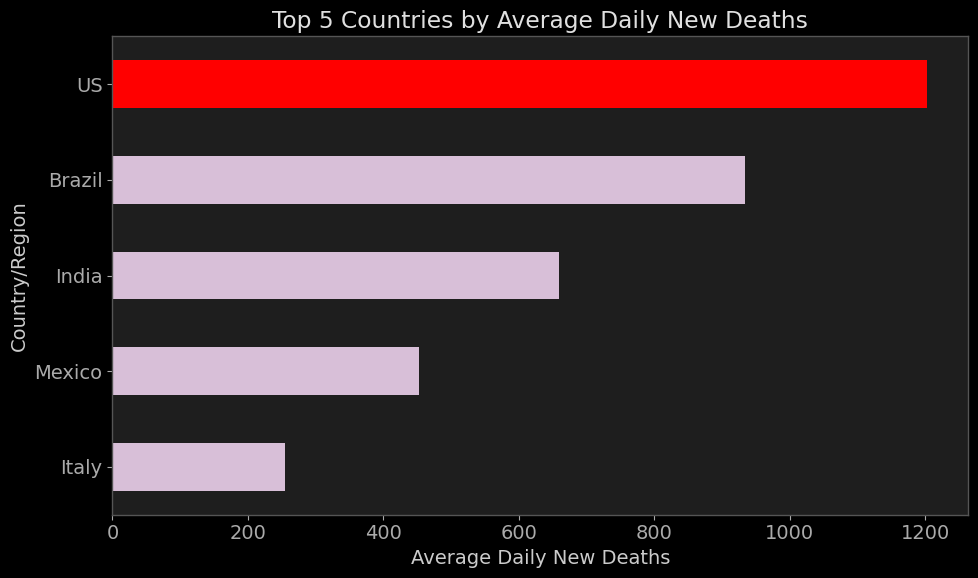

In [ ]:
fig_q6_3, ax_q6_3 = plt.subplots(figsize=(10, 6))
avg_daily_deaths.head(5).sort_values().plot(kind='barh', ax=ax_q6_3, color=['red' if value == avg_daily_deaths.max() else 'thistle' for value in avg_daily_deaths.head(5).sort_values(ascending=True)])
ax_q6_3.set_title('Top 5 Countries by Average Daily New Deaths')
ax_q6_3.set_xlabel('Average Daily New Deaths')
ax_q6_3.set_ylabel('Country/Region')
plt.tight_layout()

## Q6.4: "How have the total deaths evolved over time in the United States?"

Finally, the long format makes it incredibly easy to plot the trajectory of the pandemic for any single country. To visualize the evolution of total deaths in the United States, the steps were:

1.  **Filter for the Country:** I simply filtered the long DataFrame for rows where `Country/Region == 'US'`.
    
2.  **Aggregate Province Data:** Because the US data is broken down by state/province, I needed to perform a `groupby('Date')` and `.sum()` on this filtered data. This ensures that on any given day, I have one single, national figure for total deaths.
    
3.  **Plotting:** With a clean Series of dates and corresponding national death tolls, creating a line plot is straightforward. The resulting chart clearly shows the different waves of the pandemic in the US, marked by periods of sharp acceleration in cumulative deaths.

In [ ]:
deaths_long_US = deaths_long[deaths_long['Country/Region'] == "US"]

In [ ]:
deaths_long_US.head()

,Country/Region,Province/State,Lat,Long,Date,Counts
251,US,All Provinces,40.0,-100.0,2020-01-22,0
527,US,All Provinces,40.0,-100.0,2020-01-23,0
803,US,All Provinces,40.0,-100.0,2020-01-24,0
1079,US,All Provinces,40.0,-100.0,2020-01-25,0
1355,US,All Provinces,40.0,-100.0,2020-01-26,0


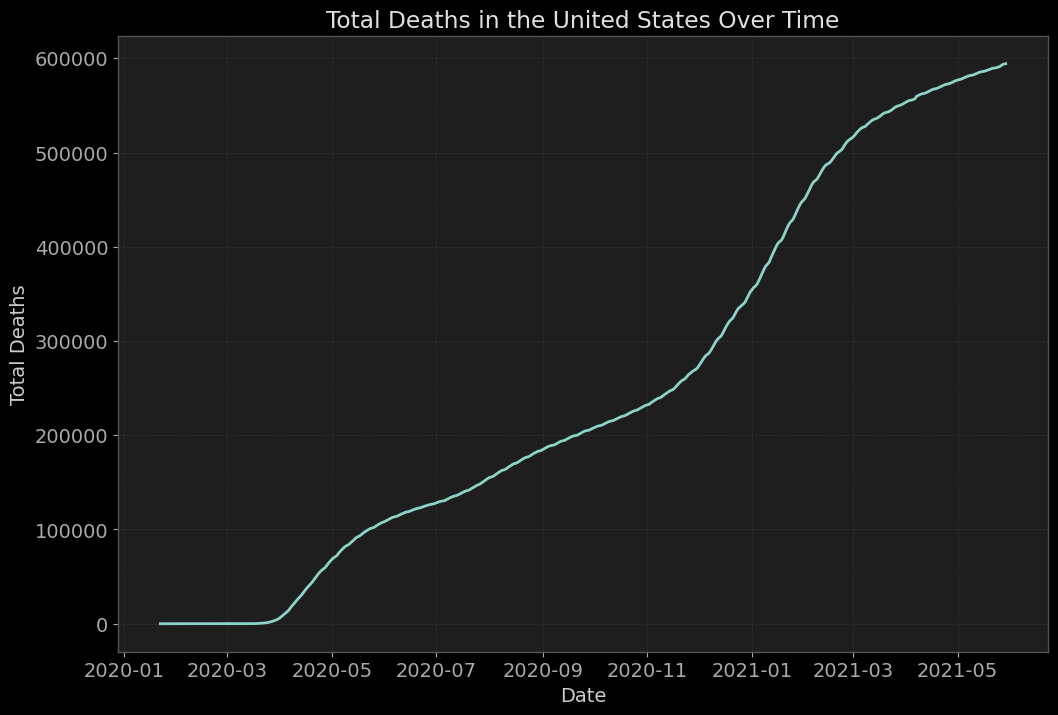

In [ ]:
plt.figure(figsize=(12,8))
plt.plot(deaths_long_US['Date'],deaths_long_US['Counts'])
plt.grid(True)
plt.xlabel('Date')
plt.ylabel('Total Deaths')
plt.title('Total Deaths in the United States Over Time')
plt.show()

In [ ]:
deaths_long_US.shape

(494, 6)

In [ ]:
deaths_long_US['Date'].nunique()

494

# Question 7: Data Merging

## **Q7.1**: How would you merge the transformed datasets of confirmed cases, deaths, and recoveries on the 'Country/Region' and 'Date' columns to create a comprehensive view of the pandemic's impact?

In [ ]:
confirmed_long['confirmed'] = confirmed_long['Counts']
confirmed_long.drop('Counts', axis=1, inplace=True)
deaths_long['deaths'] = deaths_long['Counts']
deaths_long.drop('Counts', axis=1, inplace=True)
recovered_long['recovered'] = recovered_long['Counts']
recovered_long.drop('Counts', axis=1, inplace=True)

print(confirmed_long.head())
print(deaths_long.head())
print(recovered_long.head())

  Country/Region Province/State       Lat       Long       Date  confirmed
0    Afghanistan  All Provinces  33.93911  67.709953 2020-01-22          0
1        Albania  All Provinces  41.15330  20.168300 2020-01-22          0
2        Algeria  All Provinces  28.03390   1.659600 2020-01-22          0
3        Andorra  All Provinces  42.50630   1.521800 2020-01-22          0
4         Angola  All Provinces -11.20270  17.873900 2020-01-22          0
  Country/Region Province/State       Lat       Long       Date  deaths
0    Afghanistan  All Provinces  33.93911  67.709953 2020-01-22       0
1        Albania  All Provinces  41.15330  20.168300 2020-01-22       0
2        Algeria  All Provinces  28.03390   1.659600 2020-01-22       0
3        Andorra  All Provinces  42.50630   1.521800 2020-01-22       0
4         Angola  All Provinces -11.20270  17.873900 2020-01-22       0
  Country/Region Province/State       Lat       Long       Date  recovered
0    Afghanistan  All Provinces  33.93911  

In [ ]:
confirmed_long.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136344 entries, 0 to 136343
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   Country/Region  136344 non-null  object        
 1   Province/State  136344 non-null  object        
 2   Lat             136344 non-null  float64       
 3   Long            136344 non-null  float64       
 4   Date            136344 non-null  datetime64[ns]
 5   confirmed       136344 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(1), object(2)
memory usage: 6.2+ MB


In [ ]:
deaths_long.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136344 entries, 0 to 136343
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   Country/Region  136344 non-null  object        
 1   Province/State  136344 non-null  object        
 2   Lat             136344 non-null  float64       
 3   Long            136344 non-null  float64       
 4   Date            136344 non-null  datetime64[ns]
 5   deaths          136344 non-null  Int64         
dtypes: Int64(1), datetime64[ns](1), float64(2), object(2)
memory usage: 6.4+ MB


In [ ]:
recovered_long.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128934 entries, 0 to 128933
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   Country/Region  128934 non-null  object        
 1   Province/State  128934 non-null  object        
 2   Lat             128934 non-null  float64       
 3   Long            128934 non-null  float64       
 4   Date            128934 non-null  datetime64[ns]
 5   recovered       128934 non-null  Int64         
dtypes: Int64(1), datetime64[ns](1), float64(2), object(2)
memory usage: 6.0+ MB


#### My Analysis

Having transformed all three datasets—confirmed, deaths, and recoveries—into a consistent long format, the next logical step was to merge them into a single, master DataFrame. This would allow me to analyze the relationships between these three metrics simultaneously.

**The Strategy:**

1.  **The 'Keys' for Merging:** The foundation of a successful merge is defining the 'keys'—the columns that uniquely identify a row. In our case, each unique observation is defined by its `['Country/Region', 'Province/State', 'Date']`. These are the columns I would merge on.
    
2.  **Choosing the Merge Type (`how='outer'`):** I chose to perform an **outer merge**. This was a deliberate and critical decision. An `inner` merge would only keep rows where a date and location existed in *all three* datasets. If a country reported confirmed cases but had zero deaths and zero recoveries (a common scenario at the start of an outbreak), an inner merge would drop that data entirely. An `outer` merge, on the other hand, keeps all rows from all datasets and fills in any missing values with `NaN`. This ensures no data is lost and gives us the most complete picture possible.
    
3.  **The Process:** I performed the merge in two steps: first, I merged `confirmed_long` with `deaths_long`, and then I merged that result with `recovered_long`. The result is a single, powerful DataFrame where each row contains the confirmed, death, and recovery counts for a specific place on a specific day.


In [ ]:
merged_confirm_deaths = pd.merge(left = confirmed_long.drop(['Lat','Long'], axis=1), right=deaths_long.drop(['Lat','Long'], axis=1), on=['Country/Region', 'Province/State','Date'], how='outer')

print(merged_confirm_deaths.head())

merged_confirm_deaths.info()

  Country/Region Province/State       Date  confirmed  deaths
0    Afghanistan  All Provinces 2020-01-22          0       0
1    Afghanistan  All Provinces 2020-01-23          0       0
2    Afghanistan  All Provinces 2020-01-24          0       0
3    Afghanistan  All Provinces 2020-01-25          0       0
4    Afghanistan  All Provinces 2020-01-26          0       0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136344 entries, 0 to 136343
Data columns (total 5 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   Country/Region  136344 non-null  object        
 1   Province/State  136344 non-null  object        
 2   Date            136344 non-null  datetime64[ns]
 3   confirmed       136344 non-null  int64         
 4   deaths          136344 non-null  Int64         
dtypes: Int64(1), datetime64[ns](1), int64(1), object(2)
memory usage: 5.3+ MB


In [ ]:
merged_confirm_deaths_recovered = pd.merge(left = merged_confirm_deaths, right=recovered_long.drop(['Lat','Long'], axis=1), on=['Country/Region', 'Province/State','Date'], how='outer')
merged_confirm_deaths_recovered['confirmed'] = merged_confirm_deaths_recovered['confirmed'].astype('Int64')

print(merged_confirm_deaths_recovered.head())

merged_confirm_deaths_recovered.info()

  Country/Region Province/State       Date  confirmed  deaths  recovered
0    Afghanistan  All Provinces 2020-01-22          0       0          0
1    Afghanistan  All Provinces 2020-01-23          0       0          0
2    Afghanistan  All Provinces 2020-01-24          0       0          0
3    Afghanistan  All Provinces 2020-01-25          0       0          0
4    Afghanistan  All Provinces 2020-01-26          0       0          0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136838 entries, 0 to 136837
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   Country/Region  136838 non-null  object        
 1   Province/State  136838 non-null  object        
 2   Date            136838 non-null  datetime64[ns]
 3   confirmed       136344 non-null  Int64         
 4   deaths          136344 non-null  Int64         
 5   recovered       128934 non-null  Int64         
dtypes: Int64(3), datetime64

## Q7.2: "Analyze the monthly sum of confirmed cases, deaths, and recoveries for countries to understand the progression of the pandemic. [From the merged dataset]"

#### My analysis:



**The Methodology:**

1.  **Aggregate by Country and Date:** First, I needed a clean, country-level daily view. I grouped the merged DataFrame by `Country/Region` and `Date` and summed the counts. This combined all province-level data into a national total for each day.
    
2.  **Calculate Daily New Figures:** Just as before, the data was cumulative. I used the `groupby('Country/Region').diff()` method on the confirmed, deaths, and recoveries columns to calculate the number of *new* events each day.
    
3.  **Aggregate by Month:** To get the monthly totals, I created a 'Month-Year' column and then grouped by `Country/Region` and this new column, summing up the daily figures.
    
4.  **Visualize the Waves:** I created a function to plot these monthly totals for any given country. This allows for a clear comparison of the magnitude and timing of the waves of new cases, deaths, and recoveries.

**A Critical Insight from the Visualization:**

When I plotted this for the United States, it revealed a significant **data quality issue** that I mentioned earlier. Notice the green line for recoveries—it tracks logically with confirmed cases until December 2020, at which point it becomes erratic and plummets. This is because the data source stopped updating this metric reliably for the US. This discovery is crucial because it tells us that any analysis involving US recoveries after late 2020 would be misleading.

In [ ]:
# merged_confirm_deaths_recovered['Date'].iloc[0].month

In [ ]:
# merged_confirm_deaths_recovered['Month'] = merged_confirm_deaths_recovered['Date'].apply(lambda x: x.month)

# merged_confirm_deaths_recovered.head()

In [ ]:
# for given country, for given date, how many cumulative confirmed, death and recovered
grouped_merged_data = merged_confirm_deaths_recovered.groupby(['Country/Region', 'Date'])[['confirmed','deaths','recovered']].sum().reset_index()

In [ ]:
grouped_merged_data = grouped_merged_data.sort_values(by=['Country/Region','Date'])
grouped_merged_data.head()

,Country/Region,Date,confirmed,deaths,recovered
0,Afghanistan,2020-01-22,0,0,0
1,Afghanistan,2020-01-23,0,0,0
2,Afghanistan,2020-01-24,0,0,0
3,Afghanistan,2020-01-25,0,0,0
4,Afghanistan,2020-01-26,0,0,0


In [ ]:
# calculating daily data
grouped_merged_data['daily_confirmed'] = grouped_merged_data.groupby(['Country/Region'])['confirmed'].diff().fillna(grouped_merged_data['confirmed'])
grouped_merged_data['daily_deaths'] = grouped_merged_data.groupby(['Country/Region'])['deaths'].diff().fillna(grouped_merged_data['deaths'])
grouped_merged_data['daily_recovered'] = grouped_merged_data.groupby(['Country/Region'])['recovered'].diff().fillna(grouped_merged_data['recovered'])

grouped_merged_data.head()

,Country/Region,Date,confirmed,deaths,recovered,daily_confirmed,daily_deaths,daily_recovered
0,Afghanistan,2020-01-22,0,0,0,0,0,0
1,Afghanistan,2020-01-23,0,0,0,0,0,0
2,Afghanistan,2020-01-24,0,0,0,0,0,0
3,Afghanistan,2020-01-25,0,0,0,0,0,0
4,Afghanistan,2020-01-26,0,0,0,0,0,0


In [ ]:
grouped_merged_data['Month-Year'] = grouped_merged_data['Date'].dt.to_period('M')
grouped_merged_data.head()

,Country/Region,Date,confirmed,deaths,recovered,daily_confirmed,daily_deaths,daily_recovered,Month-Year
0,Afghanistan,2020-01-22,0,0,0,0,0,0,2020-01
1,Afghanistan,2020-01-23,0,0,0,0,0,0,2020-01
2,Afghanistan,2020-01-24,0,0,0,0,0,0,2020-01
3,Afghanistan,2020-01-25,0,0,0,0,0,0,2020-01
4,Afghanistan,2020-01-26,0,0,0,0,0,0,2020-01


In [ ]:
# now what i want is - per country, per month-year -> sum of daily cases ( conf/death/recov )
grouped_merged_data.groupby(['Country/Region','Month-Year'])[['daily_confirmed','daily_deaths','daily_recovered']].sum()


daily_confirmed  daily_deaths  daily_recovered
Country/Region Month-Year                                                
Afghanistan    2020-01                   0             0                0
               2020-02                   1             0                0
               2020-03                 174             4                5
               2020-04                1952            60              255
               2020-05               13081           194             1068
...                                    ...           ...              ...
Zimbabwe       2021-01               19521           854            14794
               2021-02                2701           246             6622
               2021-03                 793            60             2020
               2021-04                1375            44              926
               2021-05                 676            27              966

[3281 rows x 3 columns]

In [ ]:
monthly_merged_df = grouped_merged_data.groupby(['Country/Region','Month-Year'])[['daily_confirmed','daily_deaths','daily_recovered']].sum().reset_index()

In [ ]:
monthly_merged_df

,Country/Region,Month-Year,daily_confirmed,daily_deaths,daily_recovered
0,Afghanistan,2020-01,0,0,0
1,Afghanistan,2020-02,1,0,0
2,Afghanistan,2020-03,174,4,5
3,Afghanistan,2020-04,1952,60,255
4,Afghanistan,2020-05,13081,194,1068
...,...,...,...,...,...
3276,Zimbabwe,2021-01,19521,854,14794
3277,Zimbabwe,2021-02,2701,246,6622
3278,Zimbabwe,2021-03,793,60,2020
3279,Zimbabwe,2021-04,1375,44,926


In [ ]:
grouped_merged_data[(grouped_merged_data['Country/Region'] == 'US') & (grouped_merged_data['Month-Year'] == '2020-12')]

,Country/Region,Date,confirmed,deaths,recovered,daily_confirmed,daily_deaths,daily_recovered,Month-Year
88740,US,2020-12-01,13858551,273566,5226581,188219,2546,80262,2020-12
88741,US,2020-12-02,14061108,276381,5322128,202557,2815,95547,2020-12
88742,US,2020-12-03,14284721,279337,5404018,223613,2956,81890,2020-12
88743,US,2020-12-04,14517506,282036,5470389,232785,2699,66371,2020-12
88744,US,2020-12-05,14733048,284390,5576026,215542,2354,105637,2020-12
88745,US,2020-12-06,14914060,285736,5624444,181012,1346,48418,2020-12
88746,US,2020-12-07,15108918,287342,5714557,194858,1606,90113,2020-12
88747,US,2020-12-08,15333410,289963,5786915,224492,2621,72358,2020-12
88748,US,2020-12-09,15555949,293146,5889896,222539,3183,102981,2020-12
88749,US,2020-12-10,15787464,296141,5985047,231515,2995,95151,2020-12


In [ ]:
grouped_merged_data[(grouped_merged_data['Country/Region'] == 'US') & (grouped_merged_data['Month-Year'] == '2021-05')]

,Country/Region,Date,confirmed,deaths,recovered,daily_confirmed,daily_deaths,daily_recovered,Month-Year
88891,US,2021-05-01,32392274,577116,0,45303,719,0,2021-05
88892,US,2021-05-02,32421641,577452,0,29367,336,0,2021-05
88893,US,2021-05-03,32472201,577944,0,50560,492,0,2021-05
88894,US,2021-05-04,32512934,578822,0,40733,878,0,2021-05
88895,US,2021-05-05,32557669,579603,0,44735,781,0,2021-05
88896,US,2021-05-06,32605183,580398,0,47514,795,0,2021-05
88897,US,2021-05-07,32652472,581154,0,47289,756,0,2021-05
88898,US,2021-05-08,32686965,581771,0,34493,617,0,2021-05
88899,US,2021-05-09,32708357,582013,0,21392,242,0,2021-05
88900,US,2021-05-10,32745255,582414,0,36898,401,0,2021-05


In [ ]:
india_monthly_data = monthly_merged_df[monthly_merged_df['Country/Region']=='India']

In [ ]:
us_monthly_data = monthly_merged_df[monthly_merged_df['Country/Region']=='US']

In [ ]:
us_monthly_data

,Country/Region,Month-Year,daily_confirmed,daily_deaths,daily_recovered
3043,US,2020-01,8,0,0
3044,US,2020-02,17,1,7
3045,US,2020-03,192276,5369,7017
3046,US,2020-04,888719,60865,146923
3047,US,2020-05,717698,41605,290811
3048,US,2020-06,843456,19767,275873
3049,US,2020-07,1925246,26550,717529
3050,US,2020-08,1459475,29661,746665
3051,US,2020-09,1208533,23399,655863
3052,US,2020-10,1930191,24532,771790


In [ ]:
# def plot_monthly_data(monthly_merged_df, country):
#   plt.figure(figsize=(12,8))
#   plt.plot(monthly_merged_df[monthly_merged_df['Country/Region']==country]['Month-Year'].astype(str),monthly_merged_df[monthly_merged_df['Country/Region']==country]['daily_confirmed'], label='Confirmed', color='blue', marker='o', linestyle='-')
#   plt.plot(monthly_merged_df[monthly_merged_df['Country/Region']==country]['Month-Year'].astype(str),monthly_merged_df[monthly_merged_df['Country/Region']==country]['daily_deaths'], label='Deaths', color='red', marker='o', linestyle='-')
#   plt.plot(monthly_merged_df[monthly_merged_df['Country/Region']==country]['Month-Year'].astype(str),monthly_merged_df[monthly_merged_df['Country/Region']==country]['daily_recovered'], label='Recovered', color='green', marker='o', linestyle='-')
#   plt.grid(True)
#   plt.tight_layout()
#   plt.xlabel('Month-Year')
#   plt.ylabel('Number of New Confirmed Cases')
#   plt.title(f'Monthly New Confirmed Cases in {country}')
#   plt.legend()
#   plt.show()

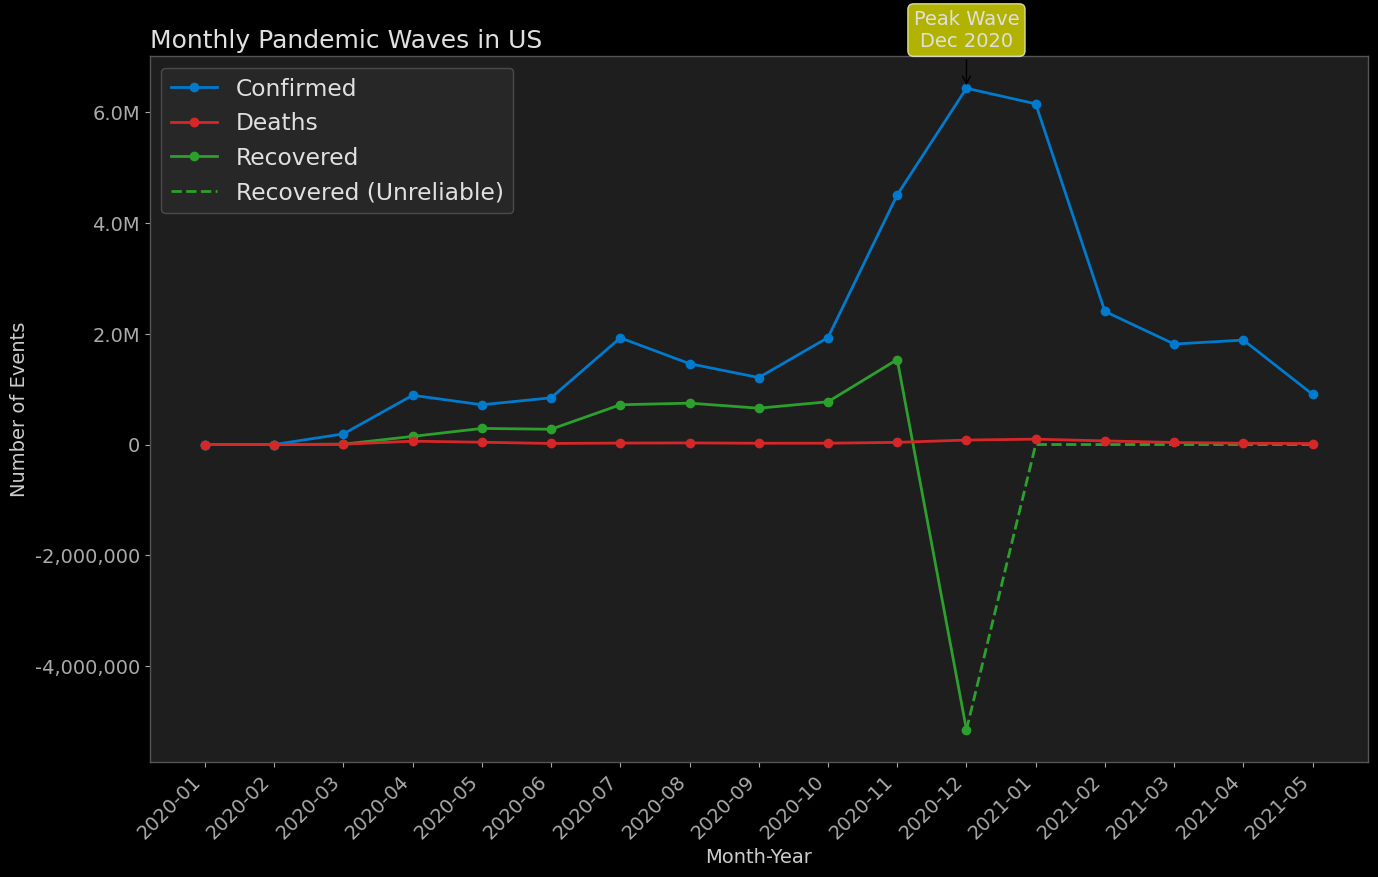

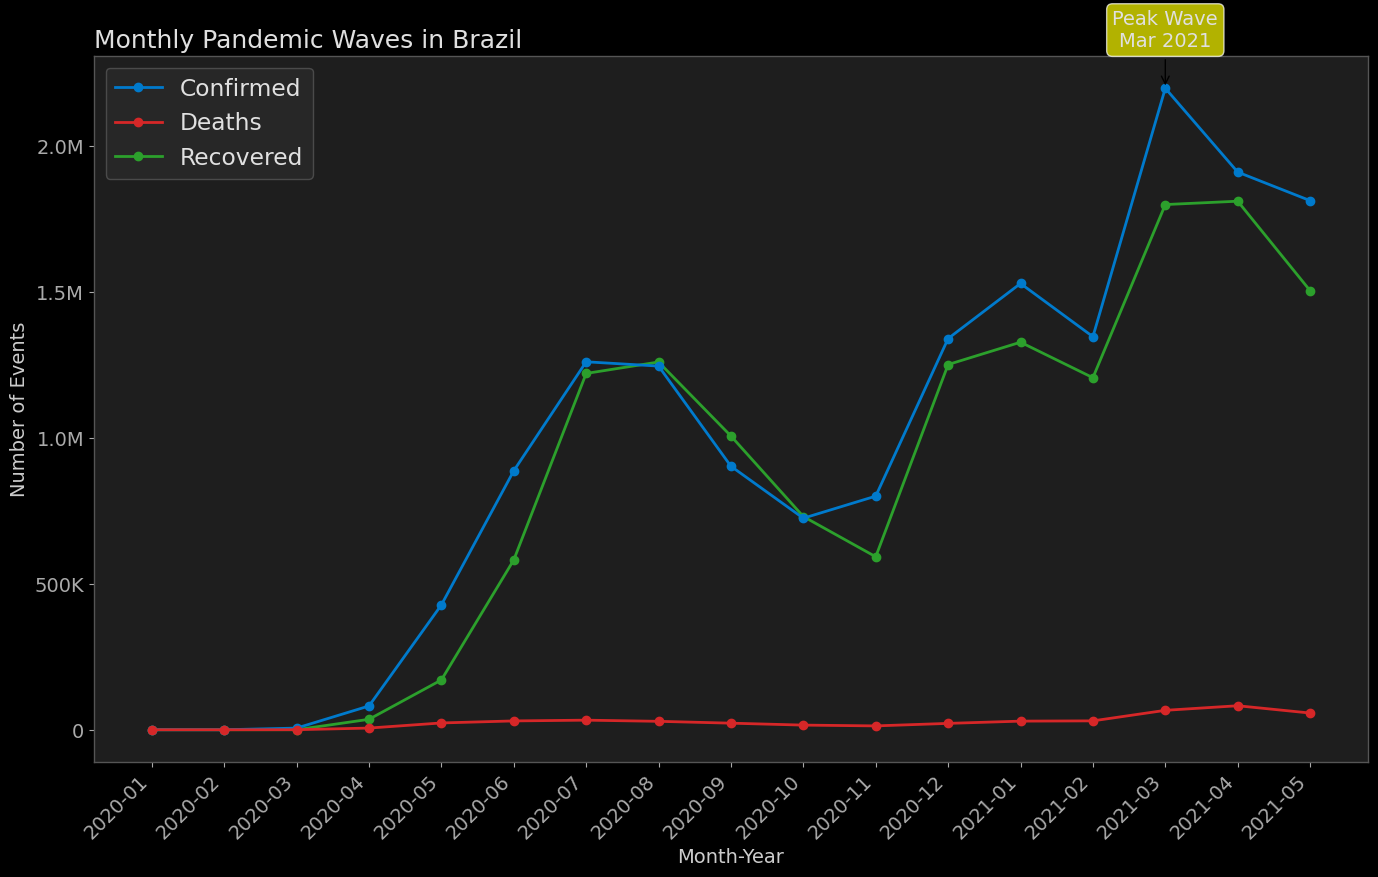

In [ ]:
def plot_monthly_data(monthly_merged_df, country):
  fig, ax = plt.subplots()

  country_data = monthly_merged_df[monthly_merged_df['Country/Region']==country]
  x_axis_labels = country_data['Month-Year'].astype(str)

  ax.plot(x_axis_labels, country_data['daily_confirmed'], label='Confirmed', color='#007acc', marker='o', zorder=3)
  ax.plot(x_axis_labels, country_data['daily_deaths'], label='Deaths', color='#d62728', marker='o', zorder=3)


  if country == 'US':
      good_recovery = country_data[country_data['Month-Year'] <= '2020-12']
      bad_recovery = country_data[country_data['Month-Year'] >= '2020-12']
      ax.plot(good_recovery['Month-Year'].astype(str), good_recovery['daily_recovered'], label='Recovered', color='#2ca02c', marker='o')
      ax.plot(bad_recovery['Month-Year'].astype(str), bad_recovery['daily_recovered'], color='#2ca02c', linestyle='--', label='Recovered (Unreliable)')
  else:
      ax.plot(x_axis_labels, country_data['daily_recovered'], label='Recovered', color='#2ca02c', marker='o')


  peak_idx = country_data['daily_confirmed'].idxmax()
  peak_date = country_data.loc[peak_idx, 'Month-Year'].strftime('%b %Y')
  peak_value = country_data.loc[peak_idx, 'daily_confirmed']
  ax.annotate(f'Peak Wave\n{peak_date}',
              xy=(str(country_data.loc[peak_idx, 'Month-Year']), peak_value),
              xytext=(0, 30), textcoords='offset points',
              ha='center', arrowprops=dict(arrowstyle="->", color='black'),
              bbox=dict(boxstyle="round,pad=0.3", fc='yellow', alpha=0.7))


  ax.set_title(f'Monthly Pandemic Waves in {country}', loc='left', fontsize=18)
  ax.set_xlabel('Month-Year')
  ax.set_ylabel('Number of Events')
  ax.yaxis.set_major_formatter(FuncFormatter(readable_formatter))

  ax.legend(loc='upper left')
  plt.xticks(rotation=45, ha="right")
  plt.tight_layout()
  plt.show()


plot_monthly_data(monthly_merged_df, 'US')
plot_monthly_data(monthly_merged_df, 'Brazil')

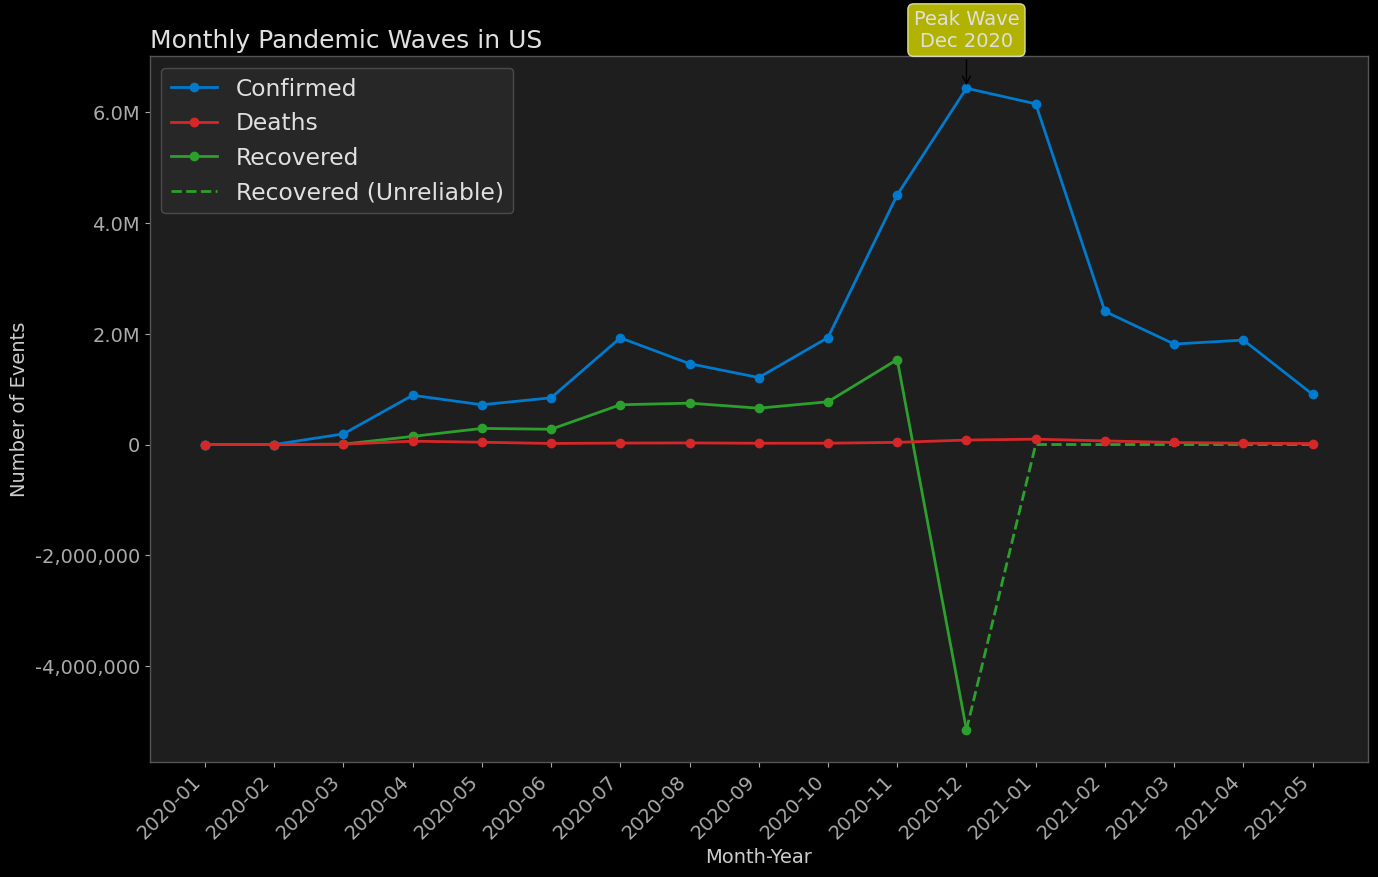

In [ ]:
plot_monthly_data(monthly_merged_df, 'US')

 This shows a data issue in the recoveries data for US -> confirmed through examining the previous datasets where recoveries data has been put as 0 after 14-12-2020, which causes the .diff() to create a large negative value

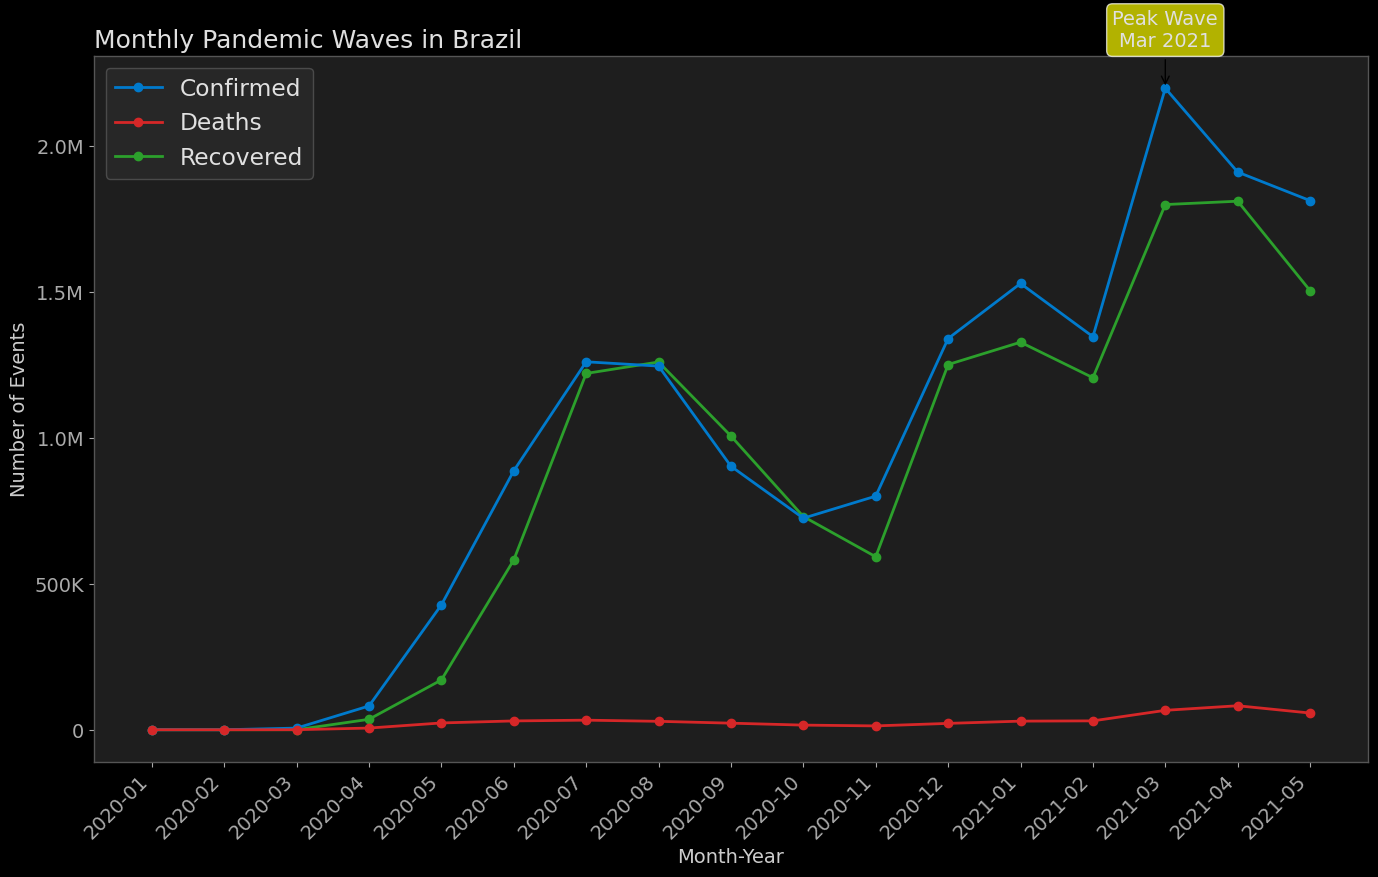

In [ ]:
plot_monthly_data(monthly_merged_df, 'Brazil')

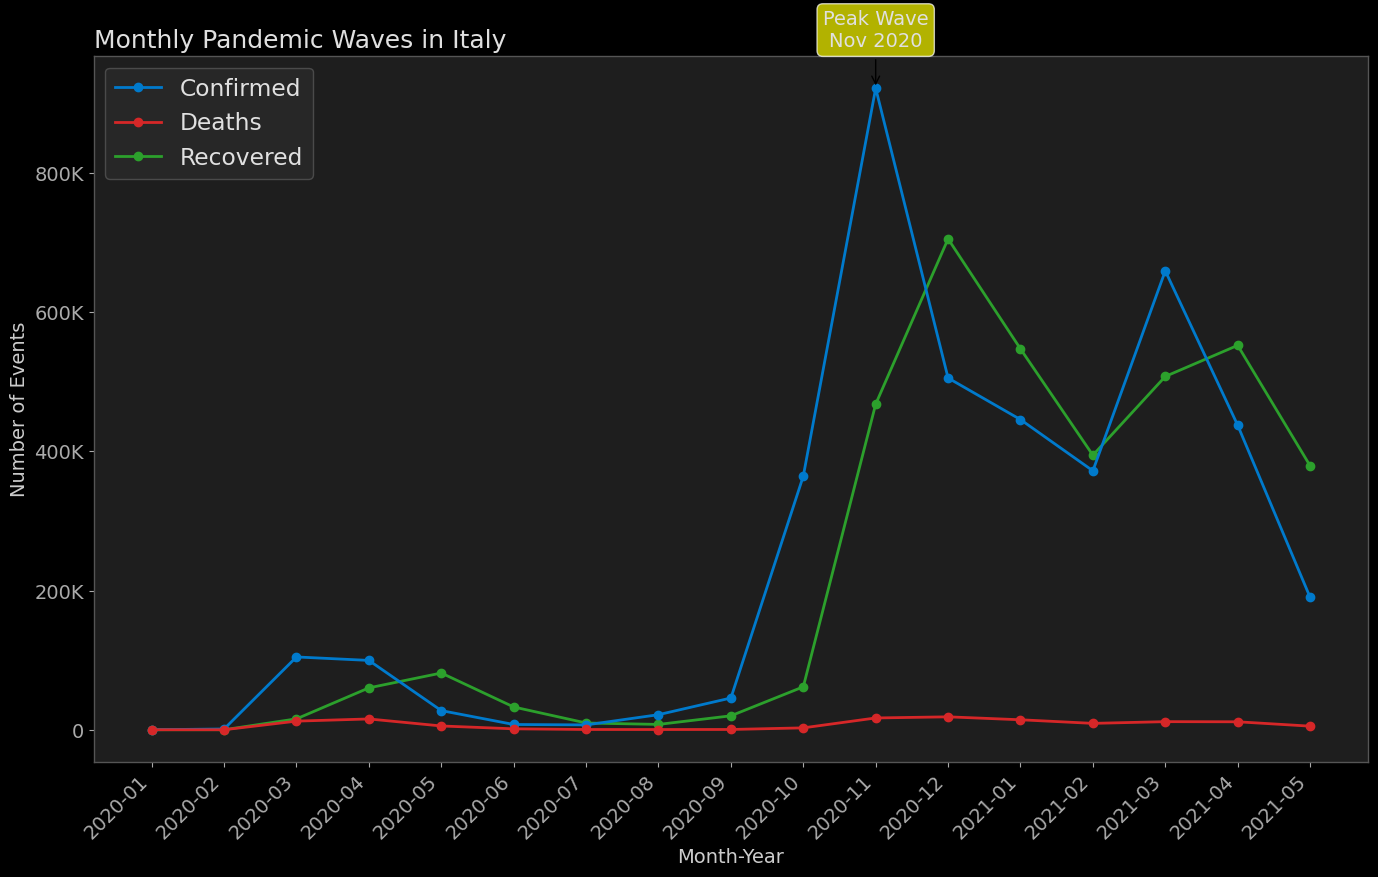

In [ ]:
plot_monthly_data(monthly_merged_df, 'Italy')

# Question 8: Combined Data Analysis

## **Q8.1**: For the combined dataset, identify the three countries with the highest average death rates (deaths/confirmed cases) throughout 2020. What might this indicate about the pandemic's impact in these countries?

#### my analysis:

the term 'death rate' can be ambiguous. Depending on how you calculate it, you can get very different results that answer slightly different questions.

So, I explored three distinct approaches to be thorough and ensure my final conclusion was based on the most appropriate methodology. Let's walk through my thought process.





#### **Approach 1: The Average of Daily Rates**

**How I Calculated It:**
My first approach was to calculate a death rate for every single day of 2020 for each country. The formula for each day was: `Daily New Deaths / Daily New Confirmed Cases`. After calculating this for all days, I took the average (the `.mean()`) of these daily rates for each country.


In [ ]:
# death rate analysis
grouped_merged_data['death_rate'] = grouped_merged_data['daily_deaths'] / grouped_merged_data['daily_confirmed'].replace(0, np.nan)
grouped_merged_data.tail()

,Country/Region,Date,confirmed,deaths,recovered,daily_confirmed,daily_deaths,daily_recovered,Month-Year,death_rate
95337,Zimbabwe,2021-05-25,38706,1587,36517,10,1,46,2021-05,0.1
95338,Zimbabwe,2021-05-26,38819,1589,36531,113,2,14,2021-05,0.017699
95339,Zimbabwe,2021-05-27,38854,1592,36541,35,3,10,2021-05,0.085714
95340,Zimbabwe,2021-05-28,38918,1592,36563,64,0,22,2021-05,0.0
95341,Zimbabwe,2021-05-29,38933,1594,36578,15,2,15,2021-05,0.133333


In [ ]:
grouped_merged_data_2020 = grouped_merged_data[grouped_merged_data['Date'].dt.year == 2020].copy()

In [ ]:
grouped_merged_data_2020.head()

,Country/Region,Date,confirmed,deaths,recovered,daily_confirmed,daily_deaths,daily_recovered,Month-Year,death_rate
0,Afghanistan,2020-01-22,0,0,0,0,0,0,2020-01,<NA>
1,Afghanistan,2020-01-23,0,0,0,0,0,0,2020-01,<NA>
2,Afghanistan,2020-01-24,0,0,0,0,0,0,2020-01,<NA>
3,Afghanistan,2020-01-25,0,0,0,0,0,0,2020-01,<NA>
4,Afghanistan,2020-01-26,0,0,0,0,0,0,2020-01,<NA>


In [ ]:
avg_daily_death_rate_2020 = grouped_merged_data_2020.groupby('Country/Region')['death_rate'].mean().sort_values(ascending=False)
avg_daily_death_rate_2020.head()

,death_rate
Country/Region,
Yemen,0.267966
MS Zaandam,0.142857
Hungary,0.104539
Mexico,0.085902
Spain,0.085496


In [ ]:
print(f"three countries with the highest average death rates (deaths/confirmed cases) throughout 2020 are : \n{avg_daily_death_rate_2020.head(3)}")

three countries with the highest average death rates (deaths/confirmed cases) throughout 2020 are : 
Country/Region
Yemen         0.267966
MS Zaandam    0.142857
Hungary       0.104539
Name: death_rate, dtype: Float64


**Pros and Cons of this Approach:**
*   **Pro:** It gives weight to every single day of the year and attempts to capture the "typical" daily fatality risk.
*   **Con (Major Flaw):** This method is extremely sensitive to outliers and reporting noise. For example, imagine a day where a country reports only 2 new cases but, due to a lag, reports 4 deaths from previous days. That one day would have a 200% death rate, which would massively skew the entire year's average upwards. Similarly, days with zero cases are ignored, which can also bias the result. It's a very 'noisy' metric.

**What Question It Answers:** On a typical day in 2020, what was the average case fatality rate in this country?" (But the answer is unreliable).

#### **Approach 2: The End-of-Year Cumulative Rate**

**How I Calculated It:**
My second approach was to create a simple snapshot at the end of the year. I took the total cumulative deaths and divided by the total cumulative confirmed cases as they stood on December 31, 2020.

In [ ]:
# another way to see is - total death/ total confirmed for 2020
eoy_data_2020 = grouped_merged_data_2020[grouped_merged_data_2020['Date'] == grouped_merged_data_2020['Date'].max()].copy()
eoy_data_2020['Annual_Death_Rate'] = eoy_data_2020['deaths'] / eoy_data_2020['confirmed'].replace(0,np.nan)
# And then:
eoy_data_2020.sort_values(by='Annual_Death_Rate', ascending=False).head(5)

,Country/Region,Date,confirmed,deaths,recovered,daily_confirmed,daily_deaths,daily_recovered,Month-Year,death_rate,Annual_Death_Rate
94204,Yemen,2020-12-31,2099,610,1394,2,0,2,2020-12,0.0,0.290615
52214,MS Zaandam,2020-12-31,9,2,7,0,0,0,2020-12,<NA>,0.222222
57154,Mexico,2020-12-31,1426094,125807,1074795,12159,910,8024,2020-12,0.074842,0.088218
26032,Ecuador,2020-12-31,212512,14034,184507,1000,11,0,2020-12,0.011,0.066039
83830,Syria,2020-12-31,11434,711,5350,90,7,54,2020-12,0.077778,0.062183


In [ ]:
print(f"three countries with the highest average death rates (deaths/confirmed cases) throughout 2020 are : \n{eoy_data_2020.sort_values(by='Annual_Death_Rate', ascending=False)[['Country/Region','Annual_Death_Rate']].head(3)}")

three countries with the highest average death rates (deaths/confirmed cases) throughout 2020 are : 
      Country/Region  Annual_Death_Rate
94204          Yemen           0.290615
52214     MS Zaandam           0.222222
57154         Mexico           0.088218


**Pros and Cons of this Approach:**
*   **Pro:** It's simple, stable, and very easy to understand. It's not affected by daily fluctuations.
*   **Con:**  It only reflects the state at a single point in time, ignoring the journey throughout the year.

**What Question It Answers:** Of every person who had ever been diagnosed with COVID-19 up to the end of 2020, what percentage had died?

#### **Approach 3: The Overall Rate for the Period (My Chosen Method)**

**How I Calculated It:**
My final and preferred approach was to calculate the total number of new deaths that occurred *only within 2020* and divide that by the total number of new cases that were confirmed *only within 2020*. This isolates the year's data perfectly.

**Pros and Cons of this Approach:**
*   **Pro:** This is the most accurate and robust method for this specific question. It uses aggregated totals, so it's not skewed by single-day reporting anomalies like Approach 1. And unlike Approach 2, it strictly uses data from the 2020 period, making it a true "2020 death rate."
*   **Con:** Like any aggregate measure, it masks the evolution of the death rate *within* the year. A country's rate might have been high in the spring but low in the fall, and this single number wouldn't show that.

**What Question It Answers:** "Of all the new COVID-19 cases that were confirmed in 2020, what percentage resulted in a death during that year?"

#### Now a qs may arise - how is approach 2 different from approach 3? both provide the same answer

Because this specific dataset begins on January 22, 2020, with nearly all countries at zero cases, **for the 2020 analysis, the final numerical result of Approach 2 and Approach 3 is virtually identical.**


---

Since the data we are using starts on January 22, 2020, there is no pre-existing cumulative data from 2019.

Therefore, for the isolated case of analyzing the full year 2020, the final numbers from **Approach 2 (the end-of-year snapshot)** and **Approach 3 (the sum of daily changes)** will be identical. The sum of all the daily changes throughout 2020 is mathematically the same as the final cumulative number on December 31st, because we started from zero.

So, the natural question is: if the numbers are the same, why do I insist that Approach 3 is the better method?

The reason is not about the result in this one specific instance, but about building code and analytical workflows that are **Robust, Generalizable, and Clear.**

#### **1. Generalizability: The Method Must Work for *Any* Time Period**

Imagine your next task is to analyze the death rate for just **Q1 of 2021 (Jan 1 to Mar 31)**.

*   **Approach 2 (Snapshot)** would fail here. If you took the snapshot on March 31, 2021, the cumulative numbers would include all the cases and deaths from 2020, making your Q1 calculation completely wrong.
*   **Approach 3 (Sum of Daily Changes)** would work perfectly. It would filter for dates between Jan 1 and Mar 31, sum up only the *daily* changes within that window, and give you the correct rate for that specific quarter.

Approach 3 builds a method that is **generalizable**. I can reuse the exact same logic to analyze any month, quarter, or custom date range without having to rewrite my code. This is a core principle of good software engineering applied to data analysis.

#### **2. Clarity of Intent: The Code Should Explain Itself**

"Let's compare the two lines of code conceptually:

*   **Approach 2 Code:** `eoy_data_2020['deaths'] / eoy_data_2020['confirmed']`
    This code says: 'Divide the numbers you find on this one specific day.'

*   **Approach 3 Code:** `grouped_data['daily_deaths'].sum() / grouped_data['daily_confirmed'].sum()`
    This code says: 'Sum up all the new deaths that happened during this period and divide by the sum of all the new cases from the same period.'

The second approach is semantically clearer. It explicitly describes the calculation that matches our question: 'What was the rate for the *entire period*?' It's a form of self-documenting code that makes the analysis easier for others (and my future self) to understand and verify."

#### **3. Robustness: The Method Should Be Immune to Future Data Changes**

Right now, the dataset starts on January 22, 2020. What if, next week, the data source is updated to include newly discovered data from December 2019?

*   **Approach 2 (Snapshot)**, which you correctly noted works *now*, would instantly become incorrect without any warning. It would start including the 2019 data in its 2020 calculation, silently corrupting the result.
*   **Approach 3 (Sum of Daily Changes)** would be completely unaffected. Because it's designed to filter for a specific date range and sum the daily values *within that range*, it doesn't matter what data exists before or after. It will always give the correct answer for the period it's asked to analyze.

In [ ]:
annual_grouped_merged_data_2020 = (grouped_merged_data_2020.groupby('Country/Region')['daily_deaths'].sum()/ grouped_merged_data_2020.groupby('Country/Region')['daily_confirmed'].sum().replace(0, np.nan)).dropna().sort_values(ascending=False)



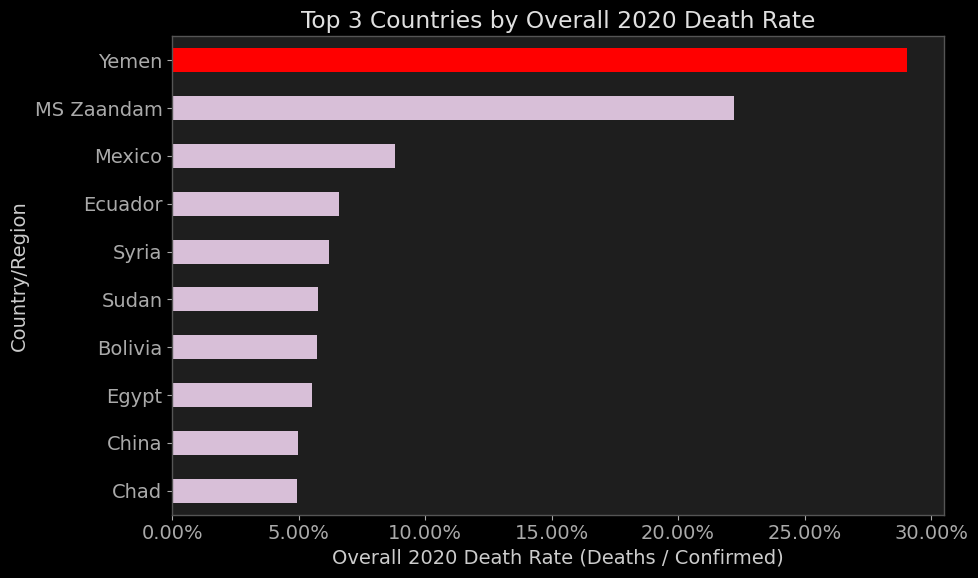

In [ ]:
fig_q8_1, ax_q8_1 = plt.subplots(figsize=(10, 6))
annual_grouped_merged_data_2020.head(10).sort_values().plot(kind='barh', ax=ax_q8_1, color = ['red' if value == annual_grouped_merged_data_2020.max() else 'thistle' for value in annual_grouped_merged_data_2020.head(10).sort_values(ascending=True)])
ax_q8_1.set_title('Top 3 Countries by Overall 2020 Death Rate')
ax_q8_1.set_xlabel('Overall 2020 Death Rate (Deaths / Confirmed)')
ax_q8_1.set_ylabel('Country/Region')
ax_q8_1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '{:.2%}'.format(x)))
plt.tight_layout()

In [ ]:
annual_grouped_merged_data_2020.head()

print(f"three countries with the highest average death rates (deaths/confirmed cases) throughout 2020 are : \n{annual_grouped_merged_data_2020.head(3)}")

three countries with the highest average death rates (deaths/confirmed cases) throughout 2020 are : 
Country/Region
Yemen         0.290615
MS Zaandam    0.222222
Mexico        0.088218
dtype: Float64


## **Q8.2**: Using the merged dataset, compare the total number of recoveries to the total number of deaths in South Africa. What can this tell us about the outcomes of COVID-19 cases in the country?

Using my final, merged dataset, I filtered for 'South Africa' and extracted the cumulative 'recovered' and 'deaths' columns for the most recent date.

In [ ]:
 sa_data = grouped_merged_data[grouped_merged_data['Country/Region'] == 'South Africa'].copy()

In [ ]:
sa_data[sa_data['Date'] == sa_data['Date'].max()]

,Country/Region,Date,confirmed,deaths,recovered,daily_confirmed,daily_deaths,daily_recovered,Month-Year,death_rate
80027,South Africa,2021-05-29,1659070,56363,1554184,4519,70,2664,2021-05,0.01549


In [ ]:
recovery_to_death_ratio = sa_data[sa_data['Date'] == sa_data['Date'].max()]['recovered'] / sa_data[sa_data['Date'] == sa_data['Date'].max()]['deaths'].replace(0, np.nan)

print(f"The recovery to death ratio of SA is {recovery_to_death_ratio.iloc[0]}")

The recovery to death ratio of SA is 27.57454358355659


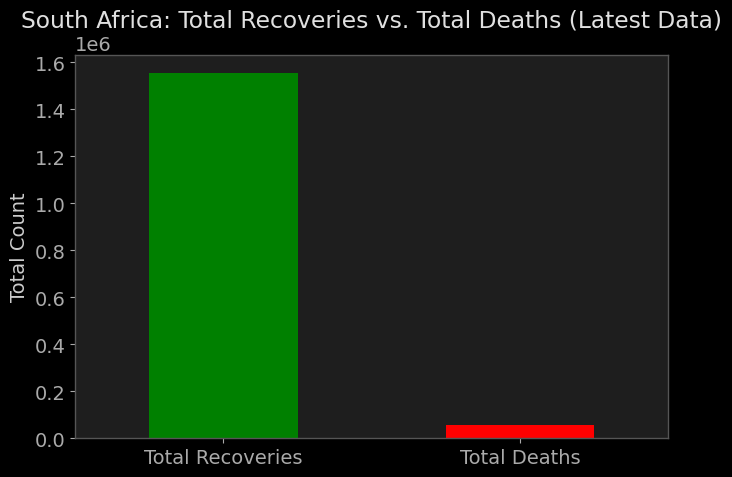

In [ ]:
latest_sa_data_q8_2 = sa_data[sa_data['Date'] == sa_data['Date'].max()] # Renaming
total_recovered_sa = latest_sa_data_q8_2['recovered'].iloc[0]
total_deaths_sa = latest_sa_data_q8_2['deaths'].iloc[0]

if not latest_sa_data_q8_2.empty:
    metrics_sa = pd.Series({'Total Recoveries': total_recovered_sa, 'Total Deaths': total_deaths_sa})
    fig_q8_2, ax_q8_2 = plt.subplots(figsize=(7, 5))
    metrics_sa.plot(kind='bar', ax=ax_q8_2, color = ['green','red'])
    ax_q8_2.set_title('South Africa: Total Recoveries vs. Total Deaths (Latest Data)')
    ax_q8_2.set_ylabel('Total Count')
    plt.xticks(rotation=0)
    plt.tight_layout()

## Q8.3: "Analyze the ratio of recoveries to confirmed cases for the United States monthly from March 2020 to May 2021. Which month experienced the highest recovery ratio, and what could be the potential reasons?"

This method involves taking a snapshot on the last day of each month and calculating the ratio of Total Cumulative Recoveries / Total Cumulative Confirmed Cases. This smooths out daily reporting noise and gives us a clear trendline of the overall situation.

In [ ]:
us_data = grouped_merged_data[(grouped_merged_data['Country/Region'] == 'US') & (grouped_merged_data['Month-Year']<='2021-05') & (grouped_merged_data['Month-Year']>='2020-03')].copy()

In [ ]:
us_data.tail()

,Country/Region,Date,confirmed,deaths,recovered,daily_confirmed,daily_deaths,daily_recovered,Month-Year,death_rate
88915,US,2021-05-25,33166418,590941,0,22756,621,0,2021-05,0.02729
88916,US,2021-05-26,33190470,591950,0,24052,1009,0,2021-05,0.041951
88917,US,2021-05-27,33217995,593288,0,27525,1338,0,2021-05,0.04861
88918,US,2021-05-28,33239963,593963,0,21968,675,0,2021-05,0.030727
88919,US,2021-05-29,33251939,594306,0,11976,343,0,2021-05,0.028641


In [ ]:
# us_monthly_totals = us_data.groupby('Month-Year')[['daily_confirmed', 'daily_recovered']].sum()
# us_monthly_totals

In [ ]:
# us_monthly_totals['cumu_recovery_rate'] = us_data.groupby('Month-Year')['recovered'].sum() / us_data.groupby('Month-Year')['confirmed'].sum().replace(0, np.nan)

# us_monthly_totals['daily_recovery_rate'] = us_data.groupby('Month-Year')['recovered'].sum() / us_data.groupby('Month-Year')['daily_confirmed'].sum().replace(0, np.nan)



In [ ]:
# us_monthly_totals

In [ ]:
# us_monthly_totals.sort_values(by='cumu_recovery_rate',ascending=False).head(1).reset_index()['Month-Year']

In [ ]:
# The month of september saw the highest recovery rate : however there are severe data quality concerns and the reasons might be myriads - change of definitions, change in healthcare practices etc

In [ ]:
# plot_data_q8_3 = us_monthly_totals.copy()
# plot_data_q8_3.index = plot_data_q8_3.index.astype(str)


# fig_q8_3, ax_q8_3 = plt.subplots(figsize=(12, 6))
# ax_q8_3.plot(plot_data_q8_3.index, plot_data_q8_3['cumu_recovery_rate'], marker='o', linestyle='-', color='#22ffa2')
# ax_q8_3.set_title('US Monthly Recovery Ratio (Recoveries /Confirmed)')
# ax_q8_3.set_xlabel('Month-Year')
# ax_q8_3.set_ylabel('Recovery Ratio')
# ax_q8_3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '{:.2%}'.format(x)))
# plt.xticks(rotation=45, ha='right')
# plt.grid(True)
# plt.tight_layout()

In [ ]:
# plot_data_q8_3 = us_monthly_totals.copy()
# plot_data_q8_3.index = plot_data_q8_3.index.astype(str)
# plot_data_q8_3['Month-Year'] = pd.to_datetime(plot_data_q8_3.index)

# fig_q8_3, ax_q8_3 = plt.subplots(figsize=(12, 6))
# filtered_plot_data_q8_3 = plot_data_q8_3[plot_data_q8_3['Month-Year'] <= '2020-12-01']
# filtered_bad_plot_data_q8_3 = plot_data_q8_3[plot_data_q8_3['Month-Year'] >= '2020-12-01']
# ax_q8_3.plot(filtered_plot_data_q8_3.index, filtered_plot_data_q8_3['cumu_recovery_rate'], marker='o', linestyle='-')


# ax_q8_3.plot(filtered_bad_plot_data_q8_3.index, filtered_bad_plot_data_q8_3['cumu_recovery_rate'],  linestyle='--')

# # if plot_data_q8_3[['Month-Year']] < '2020-12':
# #   ax_q8_3.plot(plot_data_q8_3.index, plot_data_q8_3['daily_recovery_rate'], marker='o', linestyle='-')
# ax_q8_3.set_title('US Monthly Recovery Ratio (Recoveries /Confirmed)')
# ax_q8_3.set_xlabel('Month-Year')
# ax_q8_3.set_ylabel('Daily Recovery Ratio')
# ax_q8_3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '{:.2%}'.format(x)))
# plt.xticks(rotation=45, ha='right')
# plt.grid(True)
# plt.tight_layout()

In [ ]:
# plot_data_q8_3_2 = us_monthly_totals.copy()
# plot_data_q8_3_2.index = plot_data_q8_3_2.index.astype(str)
# plot_data_q8_3_2['Month-Year'] = pd.to_datetime(plot_data_q8_3_2.index)

# fig_q8_3, ax_q8_3_2 = plt.subplots(figsize=(12, 6))
# filtered_plot_data_q8_3_2 = plot_data_q8_3_2[plot_data_q8_3['Month-Year'] <= '2020-12-01']
# filtered_bad_plot_data_q8_3_2 = plot_data_q8_3_2[plot_data_q8_3['Month-Year'] >= '2020-12-01']
# ax_q8_3_2.plot(filtered_plot_data_q8_3_2.index, filtered_plot_data_q8_3_2['daily_recovery_rate'], marker='o', linestyle='-')

# ax_q8_3_2.plot(filtered_bad_plot_data_q8_3_2.index, filtered_bad_plot_data_q8_3_2['daily_recovery_rate'],  linestyle='--')

# # if plot_data_q8_3[['Month-Year']] < '2020-12':
# #   ax_q8_3.plot(plot_data_q8_3.index, plot_data_q8_3['daily_recovery_rate'], marker='o', linestyle='-')
# ax_q8_3_2.set_title('US Monthly Recovery Ratio (Daily Recoveries / Daily Confirmed)')
# ax_q8_3_2.set_xlabel('Month-Year')
# ax_q8_3_2.set_ylabel('Daily Recovery Ratio')
# ax_q8_3_2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '{:.2%}'.format(x)))
# plt.xticks(rotation=45, ha='right')
# plt.grid(True)
# plt.tight_layout()

### Monthly recovery rate snap-shot

#### The End-of-Month Cumulative Rate

**How to Calculate It Correctly:**
This method provides a stable snapshot of the overall situation at the end of each month. It asks, 'At the end of this month, of every person who had ever been diagnosed, what percentage has recovered?'


In [ ]:
monthly_snapshots = us_data.loc[us_data.groupby('Month-Year')['Date'].idxmax()]
monthly_snapshots['cumulative_rate'] = monthly_snapshots['recovered'] / monthly_snapshots['confirmed']

monthly_snapshots.head()

,Country/Region,Date,confirmed,deaths,recovered,daily_confirmed,daily_deaths,daily_recovered,Month-Year,death_rate,cumulative_rate
88495,US,2020-03-31,192301,5370,7024,26314,1085,1380,2020-03,0.041233,0.036526
88525,US,2020-04-30,1081020,66235,153947,29220,2196,33227,2020-04,0.075154,0.142409
88556,US,2020-05-31,1798718,107840,444758,18987,615,28297,2020-05,0.032391,0.247264
88586,US,2020-06-30,2642174,127607,720631,46430,553,15428,2020-06,0.01191,0.272742
88617,US,2020-07-31,4567420,154157,1438160,68719,1237,24005,2020-07,0.018001,0.314874


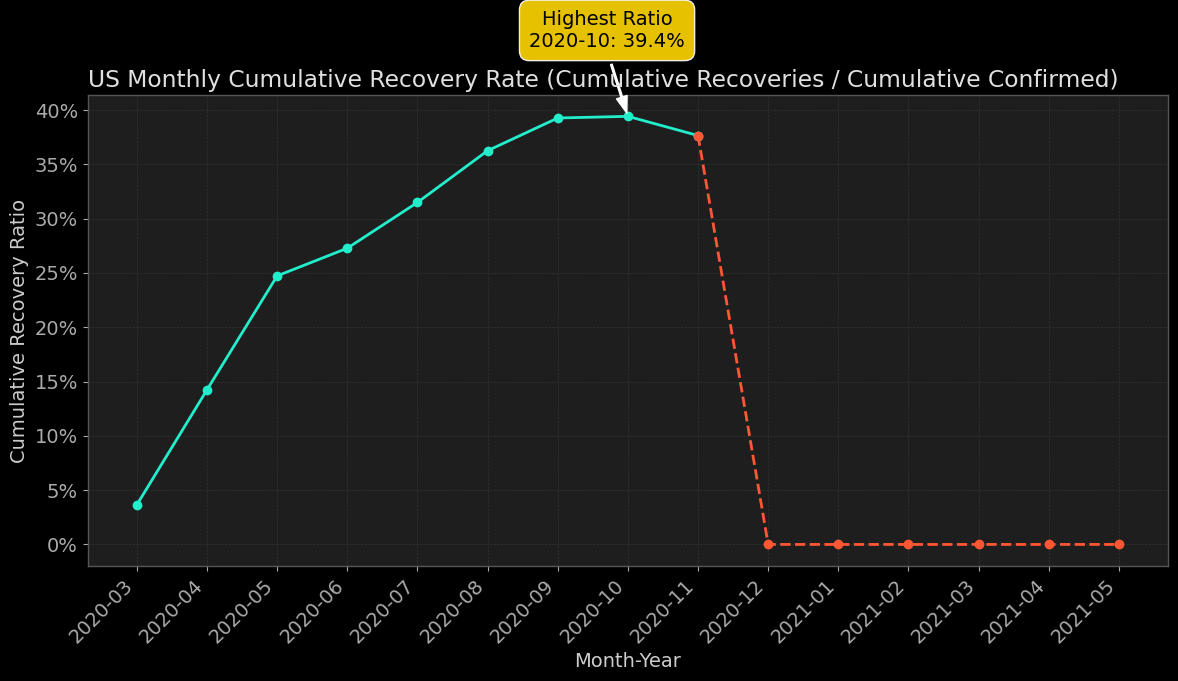

In [ ]:
monthly_snapshots.sort_values('Date', inplace=True)
monthly_snapshots['Month-Year-Str'] = monthly_snapshots['Month-Year'].astype(str)
good_data = monthly_snapshots[monthly_snapshots['Month-Year'] <= '2020-11']

bad_data = monthly_snapshots[monthly_snapshots['Month-Year'] >= '2020-11']

if not good_data.empty:
    peak_idx = good_data['cumulative_rate'].idxmax()
    peak_row = good_data.loc[peak_idx]
    peak_month_str = peak_row['Month-Year-Str'] # Use the string version for the annotation
    peak_value = peak_row['cumulative_rate']
else:
    peak_month_str, peak_value = None, None
fig_q8_3, ax_q8_3 = plt.subplots(figsize=(12, 7))

ax_q8_3.plot(good_data['Month-Year-Str'], good_data['cumulative_rate'],
             marker='o', linestyle='-', color='#22eecc', label='Recovery Rate (Reliable Data)')

ax_q8_3.plot(bad_data['Month-Year-Str'], bad_data['cumulative_rate'],
             linestyle='--', marker='o', color='#ff5733', label='Recovery Rate (Unreliable Data)')

if peak_month_str:
    ax_q8_3.annotate(
        f'Highest Ratio\n{peak_month_str}: {peak_value:.1%}',
        xy=(peak_month_str, peak_value),
        xytext=(-15, 50),
        textcoords='offset points',
        ha='center',
        color='black',
        arrowprops=dict(facecolor='white', shrink=0.05, width=1.2, headwidth=8),
        bbox=dict(boxstyle="round,pad=0.5", fc='gold', alpha=0.9)
    )


ax_q8_3.set_title('US Monthly Cumulative Recovery Rate (Cumulative Recoveries / Cumulative Confirmed)', loc='left')
ax_q8_3.set_xlabel('Month-Year')
ax_q8_3.set_ylabel('Cumulative Recovery Ratio')
ax_q8_3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '{:.0%}'.format(x)))
plt.xticks(rotation=45, ha='right')
# ax_q8_3.legend()
ax_q8_3.grid(True)
plt.tight_layout()
plt.show()